## PENALIZED LOGISTIC REGRESSION MODEL TO PREDICT OPTIMAL NEUROPLASTICITY FOLLOWING EARLY INTERVENTION IN CEREBRAL PALSY

### STUDENT NAME: STACY JEMELI NGETICH
### REGISTRATION NO:21/01021


## Analysis roadmap

| Section | Purpose | Main outputs |
|---|---|---|
| A | ONS construction | Continuous ONS, domains, internal coherence, anchor ROC, primary threshold |
| B | Predictor preparation | Completeness, structural missingness, leakage, correlations |
| C | Primary elastic-net model | Nested-CV performance, calibration, coefficients, bootstrap stability |
| D | Hypothesis models | H1–H5 estimates, interaction/joint tests, sensitivity analyses |
| E | Verification | Independent ONS reconstruction, classification checks, exposure checks |
| F | Export | Final analysis dataset, thesis tables and figures |

## A1. Import libraries, paths and reproducibility settings

In [1]:
# ============================================================
# A1. IMPORT LIBRARIES, PATHS AND REPRODUCIBILITY SETTINGS
# ============================================================

from pathlib import Path
import warnings
import os
import json
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.special import expit

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    brier_score_loss,
    accuracy_score
)

from sklearn.model_selection import (
    StratifiedKFold,
    RepeatedStratifiedKFold,
    GridSearchCV
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.calibration import calibration_curve

import statsmodels.api as sm


# ============================================================
# 1. WARNING AND DISPLAY SETTINGS
# ============================================================

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 200)
pd.set_option(
    "display.float_format",
    "{:.3f}".format
)


# ============================================================
# 2. MAIN PROJECT DIRECTORY
# ============================================================

PROJECT_DIR = Path(
    r"C:\Users\hp\Documents\MSc_Thesis_Analysis"
)


# ============================================================
# 3. INPUT AND OUTPUT DIRECTORIES
# ============================================================

RAW_DATA_DIR = (
    PROJECT_DIR / "01_Raw_Data"
)

CLEANED_DATA_DIR = (
    PROJECT_DIR / "02_Cleaned_Data"
)

ANALYSIS_DATA_DIR = (
    PROJECT_DIR / "03_Analysis_Data"
)

NOTEBOOK_DIR = (
    PROJECT_DIR / "04_Python_Notebooks"
)

RESULTS_DIR = (
    PROJECT_DIR / "05_Results"
)

FIGURE_DIR = (
    PROJECT_DIR / "06_Figures"
)

TABLE_DIR = (
    PROJECT_DIR / "07_Tables"
)

LOG_DIR = (
    PROJECT_DIR / "08_Analysis_Log"
)


# ============================================================
# 4. CREATE THE DIRECTORIES IF THEY DO NOT EXIST
# ============================================================

project_directories = [
    RAW_DATA_DIR,
    CLEANED_DATA_DIR,
    ANALYSIS_DATA_DIR,
    NOTEBOOK_DIR,
    RESULTS_DIR,
    FIGURE_DIR,
    TABLE_DIR,
    LOG_DIR
]

for directory in project_directories:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )


# ============================================================
# 5. DATASET PATHS
# ============================================================

DATA_PATH = (
    RAW_DATA_DIR
    / "Cerebral_Palsy_Optimal_Neuroplasticity_Study_Dataset.csv"
)

CLEANED_DATA_PATH = (
    CLEANED_DATA_DIR
    / "cerebral_palsy_cleaned_dataset.csv"
)

OUT_PATH = (
    ANALYSIS_DATA_DIR
    / "ons_analysis_dataset.csv"
)

LOG_PATH = (
    LOG_DIR
    / "neuroplasticity_analysis.log"
)


# ============================================================
# 6. CONFIGURE THE ANALYSIS LOG
# ============================================================

logger = logging.getLogger(
    "neuroplasticity_analysis"
)

logger.setLevel(logging.INFO)
logger.propagate = False

# Remove existing handlers when the cell is rerun
for handler in logger.handlers[:]:
    handler.close()
    logger.removeHandler(handler)

file_handler = logging.FileHandler(
    LOG_PATH,
    mode="w",
    encoding="utf-8"
)

file_handler.setFormatter(
    logging.Formatter(
        "%(asctime)s | %(levelname)s | %(message)s"
    )
)

logger.addHandler(file_handler)

logger.info(
    "Neuroplasticity analysis run started."
)


# ============================================================
# 7. ANALYSIS SETTINGS
# ============================================================

# Children below 48 months use Mini-MACS
MINI_MACS_BELOW_MONTHS = 48

# Early rehabilitation is defined as starting before 24 months
AGE_CUTOFF_MONTHS = 24

# External functional anchor
ANCHOR_COL = "Functional goals achieved?"

# Reproducibility seed
RANDOM_STATE = 42

# Number of coefficient bootstrap repetitions
N_BOOTSTRAP = 300

# Number of threshold bootstrap repetitions
N_THRESHOLD_BOOTSTRAP = 1000

# Threshold for identifying extreme standardised changes
EXTREME_THRESHOLD = 4


# ============================================================
# 8. FUNCTION FOR SAVING THESIS TABLES
# ============================================================

def save_table(table, filename, index=False):
    """
    Save a thesis-formatted table to the 07_Tables folder.
    """

    if not isinstance(
        table,
        (pd.DataFrame, pd.Series)
    ):
        raise TypeError(
            "The table must be a pandas DataFrame or Series."
        )

    path = TABLE_DIR / filename

    table.to_csv(
        path,
        index=index
    )

    logger.info(
        "Table saved: %s | rows=%s",
        path,
        len(table)
    )

    return path


# ============================================================
# 9. FUNCTION FOR SAVING ANALYSIS RESULTS
# ============================================================

def save_result(result, filename, index=False):
    """
    Save a statistical analysis result to the 05_Results folder.
    """

    if not isinstance(
        result,
        (pd.DataFrame, pd.Series)
    ):
        raise TypeError(
            "The result must be a pandas DataFrame or Series."
        )

    path = RESULTS_DIR / filename

    result.to_csv(
        path,
        index=index
    )

    logger.info(
        "Analysis result saved: %s | rows=%s",
        path,
        len(result)
    )

    return path


# ============================================================
# 10. FUNCTION FOR SAVING FIGURES
# ============================================================

def save_figure(fig, filename):
    """
    Save a thesis figure to the 06_Figures folder at 300 DPI.
    """

    path = FIGURE_DIR / filename

    fig.savefig(
        path,
        dpi=300,
        bbox_inches="tight"
    )

    logger.info(
        "Figure saved: %s",
        path
    )

    return path


# ============================================================
# 11. FUNCTION FOR SAVING TEXT RESULTS
# ============================================================

def save_text_result(text, filename):
    """
    Save a text-based analysis summary to the 05_Results folder.
    """

    path = RESULTS_DIR / filename

    with open(
        path,
        mode="w",
        encoding="utf-8"
    ) as file:
        file.write(str(text))

    logger.info(
        "Text result saved: %s",
        path
    )

    return path


# ============================================================
# 12. DISPLAY THE CONFIGURED ENVIRONMENT
# ============================================================

print("Analysis environment configured successfully.")

print("\nProject directories:")
print("Raw data:", RAW_DATA_DIR)
print("Cleaned data:", CLEANED_DATA_DIR)
print("Analysis data:", ANALYSIS_DATA_DIR)
print("Python notebooks:", NOTEBOOK_DIR)
print("Results:", RESULTS_DIR)
print("Figures:", FIGURE_DIR)
print("Tables:", TABLE_DIR)
print("Analysis log:", LOG_DIR)

print("\nMain files:")
print("Raw dataset:", DATA_PATH)
print("Cleaned dataset:", CLEANED_DATA_PATH)
print("Final analysis dataset:", OUT_PATH)
print("Analysis log file:", LOG_PATH)

logger.info(
    "Project directories configured successfully."
)

Analysis environment configured successfully.

Project directories:
Raw data: C:\Users\hp\Documents\MSc_Thesis_Analysis\01_Raw_Data
Cleaned data: C:\Users\hp\Documents\MSc_Thesis_Analysis\02_Cleaned_Data
Analysis data: C:\Users\hp\Documents\MSc_Thesis_Analysis\03_Analysis_Data
Python notebooks: C:\Users\hp\Documents\MSc_Thesis_Analysis\04_Python_Notebooks
Results: C:\Users\hp\Documents\MSc_Thesis_Analysis\05_Results
Figures: C:\Users\hp\Documents\MSc_Thesis_Analysis\06_Figures
Tables: C:\Users\hp\Documents\MSc_Thesis_Analysis\07_Tables
Analysis log: C:\Users\hp\Documents\MSc_Thesis_Analysis\08_Analysis_Log

Main files:
Raw dataset: C:\Users\hp\Documents\MSc_Thesis_Analysis\01_Raw_Data\Cerebral_Palsy_Optimal_Neuroplasticity_Study_Dataset.csv
Cleaned dataset: C:\Users\hp\Documents\MSc_Thesis_Analysis\02_Cleaned_Data\cerebral_palsy_cleaned_dataset.csv
Final analysis dataset: C:\Users\hp\Documents\MSc_Thesis_Analysis\03_Analysis_Data\ons_analysis_dataset.csv
Analysis log file: C:\Users\hp\

## A2. Load and verify the raw dataset

In [2]:
raw = pd.read_csv(DATA_PATH)
logger.info("Raw dataset loaded: %s | rows=%s | columns=%s", DATA_PATH, raw.shape[0], raw.shape[1])

# Basic reproducible cleaning: normalise labels, blank strings and exact duplicates.
df = raw.copy()
df.columns = df.columns.str.strip()
text_columns = df.select_dtypes(include=["object", "string"]).columns
for column in text_columns:
    df[column] = df[column].astype("string").str.strip().replace(r"^$", pd.NA, regex=True)
duplicate_rows_removed = int(df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)

assert df["Participant Study ID"].is_unique, "Participant Study ID is not unique."
assert len(df) == 416, f"Expected the current 416-record analytical dataset, found {len(df)}."

df.to_csv(CLEANED_DATA_PATH, index=False)
logger.info("Cleaned dataset saved: %s | rows=%s | columns=%s | exact duplicates removed=%s", CLEANED_DATA_PATH, df.shape[0], df.shape[1], duplicate_rows_removed)

print(f"Cleaned dataset shape: {df.shape}")
print("Cleaned dataset saved to:", CLEANED_DATA_PATH)
print(f"Unique participant IDs: {df['Participant Study ID'].nunique()}")
display(
    pd.DataFrame({
        "Measure": ["Participants", "Variables", "Unique IDs"],
        "Value": [len(df), df.shape[1], df["Participant Study ID"].nunique()]
    })
)

Cleaned dataset shape: (416, 175)
Cleaned dataset saved to: C:\Users\hp\Documents\MSc_Thesis_Analysis\02_Cleaned_Data\cerebral_palsy_cleaned_dataset.csv
Unique participant IDs: 416


,Measure,Value
0,Participants,416
1,Variables,175
2,Unique IDs,416


# PART A — OPTIMAL NEUROPLASTICITY SCORE (ONS)

The ONS is constructed from Week 0 to Week 12 absolute change. Percentage change and the Functional Improvement Index are excluded. Six equally weighted domains are used.

## A3. Direction-harmonise ordinal classifications and select MACS or Mini-MACS

In [3]:
LEVEL = {
    "Level I": 1,
    "Level II": 2,
    "Level III": 3,
    "Level IV": 4,
    "Level V": 5
}

def harmonise(series):
    """H = 6 - L, so higher values consistently represent better function."""
    out = 6 - series.map(LEVEL)
    if out.isna().any():
        raise ValueError(f"Unmapped or missing levels found in {series.name}.")
    return out

age = df["Child age at enrolment (months)"]
use_mini = age < MINI_MACS_BELOW_MONTHS

H_macs_0 = pd.Series(
    np.where(
        use_mini,
        harmonise(df["Mini-MACS level at baseline"]),
        harmonise(df["MACS level at baseline"])
    ),
    index=df.index
)
H_macs_12 = pd.Series(
    np.where(
        use_mini,
        harmonise(df["Mini-MACS level at follow-up"]),
        harmonise(df["MACS level at follow-up"])
    ),
    index=df.index
)

print(f"Mini-MACS used for participants aged < {MINI_MACS_BELOW_MONTHS} months.")
print(f"MACS used for participants aged >= {MINI_MACS_BELOW_MONTHS} months.")
print("Mini-MACS selected:", int(use_mini.sum()))
print("MACS selected:", int((~use_mini).sum()))

Mini-MACS used for participants aged < 48 months.
MACS used for participants aged >= 48 months.
Mini-MACS selected: 198
MACS selected: 218


## A4. Compute and standardise the eight longitudinal indicators

In [4]:
delta = pd.DataFrame(index=df.index)

delta["GMFM_total"] = (
    df["GMFM total score at follow-up (%)"]
    - df["GMFM total score at baseline (%)"]
)

delta["MACS_or_Mini"] = H_macs_12 - H_macs_0

delta["VABS_overall"] = (
    df["VABS overall/composite score at follow-up"]
    - df["VABS overall/composite score at baseline"]
)

delta["CFCS"] = (
    harmonise(df["CFCS level at follow-up"])
    - harmonise(df["CFCS level at baseline"])
)

delta["VABS_comm"] = (
    df["VABS communication domain.1"]
    - df["VABS communication domain"]
)

delta["CPQoL_particip"] = (
    df["CPQoL participation domain.1"]
    - df["CPQoL participation domain"]
)

delta["VABS_social"] = (
    df["VABS socialization domain.1"]
    - df["VABS socialization domain"]
)

delta["CPQoL_overall"] = (
    df["CPQoL overall score at follow-up"]
    - df["CPQoL overall score at baseline"]
)

assert delta.isna().sum().sum() == 0

z = (delta - delta.mean()) / delta.std(ddof=1)

change_summary = pd.DataFrame({
    "Indicator": delta.columns,
    "N": delta.count().values,
    "Mean change": delta.mean().values,
    "SD": delta.std(ddof=1).values,
    "Minimum": delta.min().values,
    "Maximum": delta.max().values
}).round(3)

z_summary = pd.DataFrame({
    "Indicator": z.columns,
    "Mean Z": z.mean().values,
    "SD Z": z.std(ddof=1).values,
    "Minimum Z": z.min().values,
    "Maximum Z": z.max().values
}).round(3)

display(change_summary)
save_table(change_summary, "Table_A1_Longitudinal_Change_Summary.csv")
display(z_summary)
save_table(z_summary, "Table_A2_Standardised_Change_Summary.csv")

,Indicator,N,Mean change,SD,Minimum,Maximum
0,GMFM_total,416,12.063,8.304,-4.400,84.000
1,MACS_or_Mini,416,0.334,1.854,-4.000,4.000
2,VABS_overall,416,8.734,5.637,-11.525,58.250
3,CFCS,416,0.356,1.784,-4.000,4.000
4,VABS_comm,416,3.325,5.319,-6.100,73.000
5,CPQoL_particip,416,4.824,4.609,-10.000,30.000
6,VABS_social,416,2.635,5.015,-39.600,53.000
7,CPQoL_overall,416,7.752,5.099,-9.000,31.670


,Indicator,Mean Z,SD Z,Minimum Z,Maximum Z
0,GMFM_total,-0.000,1.000,-1.983,8.663
1,MACS_or_Mini,0.000,1.000,-2.338,1.977
2,VABS_overall,0.000,1.000,-3.594,8.784
3,CFCS,-0.000,1.000,-2.441,2.042
4,VABS_comm,0.000,1.000,-1.772,13.100
5,CPQoL_particip,-0.000,1.000,-3.216,5.462
6,VABS_social,-0.000,1.000,-8.422,10.043
7,CPQoL_overall,0.000,1.000,-3.285,4.690


WindowsPath('C:/Users/hp/Documents/MSc_Thesis_Analysis/07_Tables/Table_A2_Standardised_Change_Summary.csv')

## A5. Identify and document extreme standardised changes

In [5]:
extreme_mask = z.abs() > EXTREME_THRESHOLD

extreme_summary = pd.DataFrame({
    "Indicator": z.columns,
    "N extreme |Z| > 4": extreme_mask.sum().values
})

extreme_records = []
for col in z.columns:
    for idx in z.index[z[col].abs() > EXTREME_THRESHOLD]:
        extreme_records.append({
            "Participant Study ID": df.loc[idx, "Participant Study ID"],
            "Indicator": col,
            "Raw change": delta.loc[idx, col],
            "Z-score": z.loc[idx, col]
        })

extreme_records = pd.DataFrame(extreme_records)

display(extreme_summary)
save_table(extreme_summary, "Table_A3_Extreme_Change_Summary.csv")

if not extreme_records.empty:
    display(extreme_records.sort_values(["Indicator", "Z-score"]).round(3))
    save_table(extreme_records, "Table_A4_Extreme_Change_Records.csv")

print("Extreme observations are flagged, not automatically deleted.")

,Indicator,N extreme |Z| > 4
0,GMFM_total,3
1,MACS_or_Mini,0
2,VABS_overall,2
3,CFCS,0
4,VABS_comm,3
5,CPQoL_particip,3
6,VABS_social,4
7,CPQoL_overall,2


,Participant Study ID,Indicator,Raw change,Z-score
16,CH0004,CPQoL_overall,28.330,4.035
15,CH0002,CPQoL_overall,31.670,4.690
10,CH0004,CPQoL_particip,25.000,4.377
8,CH0001,CPQoL_particip,30.000,5.462
9,CH0002,CPQoL_particip,30.000,5.462
0,CH0001,GMFM_total,50.000,4.569
2,CH0004,GMFM_total,68.000,6.736
1,CH0002,GMFM_total,84.000,8.663
5,CH0001,VABS_comm,37.320,6.392
6,CH0002,VABS_comm,45.000,7.836


Extreme observations are flagged, not automatically deleted.


## A6. Construct the six ONS domains and continuous ONS

In [6]:
def build_domains(zscores):
    return pd.DataFrame({
        "Gross Motor Function": zscores["GMFM_total"],
        "Manual Ability": zscores["MACS_or_Mini"],
        "Adaptive Functioning": zscores["VABS_overall"],
        "Communication": (
            zscores["CFCS"] + zscores["VABS_comm"]
        ) / 2,
        "Participation": (
            zscores["CPQoL_particip"] + zscores["VABS_social"]
        ) / 2,
        "Health-Related Quality of Life": zscores["CPQoL_overall"]
    })

domains = build_domains(z)
ONS = domains.mean(axis=1)

ons_summary = pd.DataFrame({
    "Measure": ["Mean", "SD", "Minimum", "Median", "Maximum"],
    "ONS": [
        ONS.mean(),
        ONS.std(ddof=1),
        ONS.min(),
        ONS.median(),
        ONS.max()
    ]
}).round(3)

display(ons_summary)
save_table(ons_summary, "Table_A5_Continuous_ONS_Summary.csv")

domain_summary = domains.agg(["mean", "std", "min", "median", "max"]).T.round(3)
display(domain_summary)
save_table(
    domain_summary.reset_index().rename(columns={"index": "Domain"}),
    "Table_A6_ONS_Domain_Summary.csv"
)

,Measure,ONS
0,Mean,-0.000
1,SD,0.643
2,Minimum,-1.940
3,Median,-0.000
4,Maximum,5.695


,mean,std,min,median,max
Gross Motor Function,-0.000,1.000,-1.983,-0.056,8.663
Manual Ability,0.000,1.000,-2.338,-0.180,1.977
Adaptive Functioning,0.000,1.000,-3.594,0.012,8.784
Communication,0.000,0.731,-1.956,-0.036,7.011
Participation,-0.000,0.837,-5.276,-0.049,7.752
Health-Related Quality of Life,0.000,1.000,-3.285,0.019,4.690


WindowsPath('C:/Users/hp/Documents/MSc_Thesis_Analysis/07_Tables/Table_A6_ONS_Domain_Summary.csv')

## A7. Internal coherence, domain correlations and descriptive reliability

In [7]:
domain_correlations = domains.corr(method="pearson").round(3)
display(domain_correlations)
save_table(
    domain_correlations.reset_index().rename(columns={"index": "Domain"}),
    "Table_A7_ONS_Domain_Correlations.csv"
)

k = domains.shape[1]
alpha = k / (k - 1) * (
    1 - domains.var(ddof=1).sum() / domains.sum(axis=1).var(ddof=1)
)

coherence_table = pd.DataFrame({
    "Measure": ["Cronbach alpha", "Number of domains"],
    "Value": [alpha, k]
}).round(3)

display(coherence_table)
save_table(coherence_table, "Table_A8_ONS_Internal_Coherence.csv")

print("Cronbach alpha is treated as a descriptive internal-consistency check, not as evidence that the domains are interchangeable.")

,Gross Motor Function,Manual Ability,Adaptive Functioning,Communication,Participation,Health-Related Quality of Life
Gross Motor Function,1.000,0.049,0.530,0.374,0.485,0.399
Manual Ability,0.049,1.000,0.198,0.526,0.103,0.109
Adaptive Functioning,0.530,0.198,1.000,0.562,0.628,0.498
Communication,0.374,0.526,0.562,1.000,0.375,0.289
Participation,0.485,0.103,0.628,0.375,1.000,0.607
Health-Related Quality of Life,0.399,0.109,0.498,0.289,0.607,1.000


,Measure,Value
0,Cronbach alpha,0.778
1,Number of domains,6.000


Cronbach alpha is treated as a descriptive internal-consistency check, not as evidence that the domains are interchangeable.


## A8. Sensitivity analyses for extreme values and MACS/Mini-MACS choice

In [8]:
# Winsorised sensitivity analysis
z_w3 = z.clip(-3, 3)
domains_w3 = build_domains(z_w3)
ONS_w3 = domains_w3.mean(axis=1)

sensitivity_ons = pd.DataFrame({
    "ONS version": ["Primary", "Winsorised at ±3"],
    "Mean": [ONS.mean(), ONS_w3.mean()],
    "SD": [ONS.std(ddof=1), ONS_w3.std(ddof=1)],
    "Minimum": [ONS.min(), ONS_w3.min()],
    "Maximum": [ONS.max(), ONS_w3.max()],
    "Pearson r with primary": [1.000, np.corrcoef(ONS, ONS_w3)[0, 1]],
    "Spearman rho with primary": [1.000, stats.spearmanr(ONS, ONS_w3).statistic]
}).round(3)

display(sensitivity_ons)
save_table(sensitivity_ons, "Table_A9_ONS_Winsorisation_Sensitivity.csv")

def ons_with_macs_rule(rule):
    if rule == "macs":
        manual = (
            harmonise(df["MACS level at follow-up"])
            - harmonise(df["MACS level at baseline"])
        )
    elif rule == "mini":
        manual = (
            harmonise(df["Mini-MACS level at follow-up"])
            - harmonise(df["Mini-MACS level at baseline"])
        )
    else:
        raise ValueError("rule must be 'macs' or 'mini'.")

    manual_z = (manual - manual.mean()) / manual.std(ddof=1)
    z_alt = z.copy()
    z_alt["MACS_or_Mini"] = manual_z
    return build_domains(z_alt).mean(axis=1)

macs_only = ons_with_macs_rule("macs")
mini_only = ons_with_macs_rule("mini")

macs_sensitivity = pd.DataFrame({
    "ONS version": ["MACS-only", "Mini-MACS-only"],
    "Pearson r with primary": [
        np.corrcoef(ONS, macs_only)[0, 1],
        np.corrcoef(ONS, mini_only)[0, 1]
    ],
    "Spearman rho with primary": [
        stats.spearmanr(ONS, macs_only).statistic,
        stats.spearmanr(ONS, mini_only).statistic
    ]
}).round(3)

display(macs_sensitivity)
save_table(macs_sensitivity, "Table_A10_MACS_MiniMACS_Sensitivity.csv")

,ONS version,Mean,SD,Minimum,Maximum,Pearson r with primary,Spearman rho with primary
0,Primary,-0.000,0.643,-1.940,5.695,1.000,1.000
1,Winsorised at ±3,-0.016,0.529,-1.874,2.613,0.951,1.000


,ONS version,Pearson r with primary,Spearman rho with primary
0,MACS-only,0.995,0.989
1,Mini-MACS-only,0.985,0.971


WindowsPath('C:/Users/hp/Documents/MSc_Thesis_Analysis/07_Tables/Table_A10_MACS_MiniMACS_Sensitivity.csv')

## A9. External functional anchor, ROC analysis and primary ONS threshold

In [9]:
anchor = (
    df[ANCHOR_COL]
    .astype("string")
    .str.strip()
    .str.lower()
    .eq("yes")
    .astype(int)
)

auc_ons = roc_auc_score(anchor, ONS)

fpr, tpr, thresholds_roc = roc_curve(anchor, ONS)
youden_values = tpr - fpr
best_idx = np.argmax(youden_values)
ONS_cutoff = thresholds_roc[best_idx]

ONS_anchor_binary = (ONS >= ONS_cutoff).astype(int)

tn, fp, fn, tp = confusion_matrix(anchor, ONS_anchor_binary).ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
youden_j = sensitivity + specificity - 1

anchor_table = pd.DataFrame({
    "Measure": [
        "Anchor prevalence",
        "ONS AUC",
        "Primary ONS cut-off",
        "Sensitivity",
        "Specificity",
        "Youden index"
    ],
    "Value": [
        anchor.mean(),
        auc_ons,
        ONS_cutoff,
        sensitivity,
        specificity,
        youden_j
    ]
}).round(3)

display(anchor_table)
save_table(
    anchor_table,
    "Table_A11_ONS_Anchor_ROC_Summary.csv"
)
save_result(
    anchor_table,
    "ONS_Anchor_ROC_Results.csv"
)

confusion_table = pd.DataFrame(
    confusion_matrix(anchor, ONS_anchor_binary),
    index=["Anchor: No", "Anchor: Yes"],
    columns=["ONS: 0", "ONS: 1"]
)
save_result(
    confusion_table.reset_index(),
    "ONS_Anchor_Confusion_Matrix.csv"
)
display(confusion_table)
confusion_table.to_csv(TABLE_DIR / "Table_A12_ONS_Anchor_Confusion_Matrix.csv")

,Measure,Value
0,Anchor prevalence,0.834
1,ONS AUC,0.895
2,Primary ONS cut-off,-0.237
3,Sensitivity,0.807
4,Specificity,0.870
5,Youden index,0.676


,ONS: 0,ONS: 1
Anchor: No,60,9
Anchor: Yes,67,280


## A10. Bootstrap stability of the anchor-derived threshold and alternative thresholds

In [10]:
rng = np.random.default_rng(RANDOM_STATE)
bootstrap_cutoffs = []

for _ in range(N_THRESHOLD_BOOTSTRAP):
    idx = rng.integers(0, len(ONS), len(ONS))
    if anchor.iloc[idx].nunique() == 2:
        fpr_b, tpr_b, thr_b = roc_curve(anchor.iloc[idx], ONS.iloc[idx])
        bootstrap_cutoffs.append(thr_b[np.argmax(tpr_b - fpr_b)])

threshold_ci = np.percentile(bootstrap_cutoffs, [2.5, 97.5])

thresholds = {
    "anchor (Youden)": ONS_cutoff,
    "median": ONS.median(),
    "top tertile": ONS.quantile(2 / 3)
}

threshold_table = pd.DataFrame({
    "Threshold": list(thresholds.keys()),
    "Cut-off": list(thresholds.values()),
    "Optimal n": [int((ONS >= c).sum()) for c in thresholds.values()],
    "Optimal prevalence (%)": [
        100 * (ONS >= c).mean() for c in thresholds.values()
    ]
}).round(3)

display(threshold_table)
save_table(threshold_table, "Table_A13_Candidate_ONS_Thresholds.csv")
save_result(threshold_table, "ONS_Candidate_Threshold_Results.csv")

bootstrap_table = pd.DataFrame({
    "Measure": [
        "Original Youden cut-off",
        "Bootstrap mean",
        "Bootstrap median",
        "Bootstrap SD",
        "2.5th percentile",
        "97.5th percentile"
    ],
    "Value": [
        ONS_cutoff,
        np.mean(bootstrap_cutoffs),
        np.median(bootstrap_cutoffs),
        np.std(bootstrap_cutoffs, ddof=1),
        threshold_ci[0],
        threshold_ci[1]
    ]
}).round(3)

display(bootstrap_table)
save_table(bootstrap_table, "Table_A14_ONS_Threshold_Bootstrap_Stability.csv")
save_result(bootstrap_table, "ONS_Threshold_Bootstrap_Results.csv")

,Threshold,Cut-off,Optimal n,Optimal prevalence (%)
0,anchor (Youden),-0.237,289,69.471
1,median,-0.000,208,50.000
2,top tertile,0.190,139,33.413


,Measure,Value
0,Original Youden cut-off,-0.237
1,Bootstrap mean,-0.227
2,Bootstrap median,-0.237
3,Bootstrap SD,0.074
4,2.5th percentile,-0.367
5,97.5th percentile,-0.134


WindowsPath('C:/Users/hp/Documents/MSc_Thesis_Analysis/05_Results/ONS_Threshold_Bootstrap_Results.csv')

## A11. Freeze the primary binary ONS outcome

In [11]:
df["ONS_continuous"] = ONS
df["ONS_binary"] = (ONS >= ONS_cutoff).astype(int)

outcome_table = (
    df["ONS_binary"]
    .value_counts()
    .sort_index()
    .rename(index={0: "Suboptimal ONS (0)", 1: "Optimal ONS (1)"})
    .to_frame("Count")
)
outcome_table["Percentage"] = outcome_table["Count"] / len(df) * 100
display(outcome_table.round(1))

assert df["ONS_binary"].sum() == 289
assert (df["ONS_binary"] == 0).sum() == 127

save_table(
    outcome_table.reset_index().rename(columns={"index": "ONS classification"}),
    "Table_A15_Primary_Binary_ONS_Distribution.csv"
)

print(f"Primary ONS cut-off: {ONS_cutoff:.3f}")
print(f"Optimal ONS: {df['ONS_binary'].sum()} ({df['ONS_binary'].mean()*100:.1f}%)")
print(f"Suboptimal ONS: {(df['ONS_binary']==0).sum()} ({(df['ONS_binary']==0).mean()*100:.1f}%)")

,Count,Percentage
ONS_binary,,
Suboptimal ONS (0),127,30.500
Optimal ONS (1),289,69.500


Primary ONS cut-off: -0.237
Optimal ONS: 289 (69.5%)
Suboptimal ONS: 127 (30.5%)


## A12. Thesis figures — ONS distribution and threshold/ROC

Saved: C:\Users\hp\Documents\MSc_Thesis_Analysis\06_Figures\Figure_4_1_Primary_Binary_ONS_Distribution.png


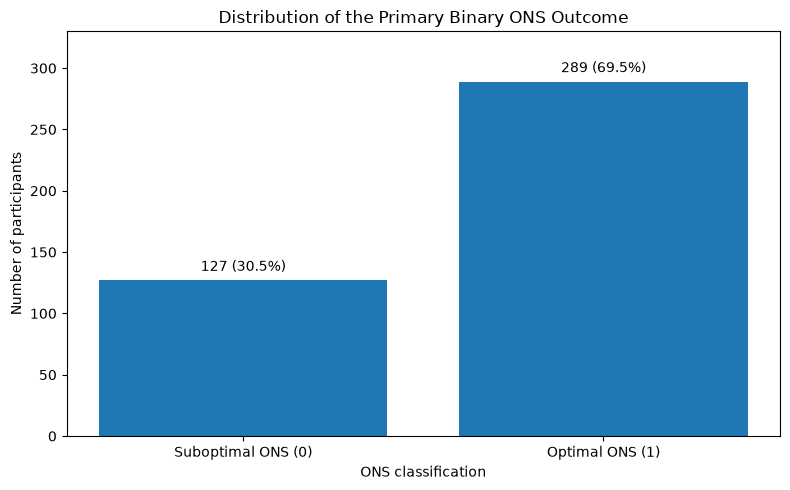

Saved: C:\Users\hp\Documents\MSc_Thesis_Analysis\06_Figures\Figure_4_2_Continuous_ONS_Thresholds.png


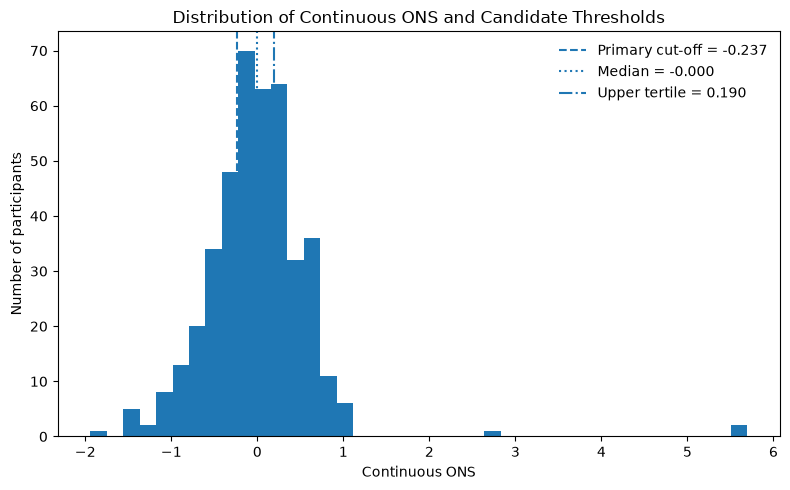

Saved: C:\Users\hp\Documents\MSc_Thesis_Analysis\06_Figures\Figure_4_3_ONS_Anchor_ROC.png


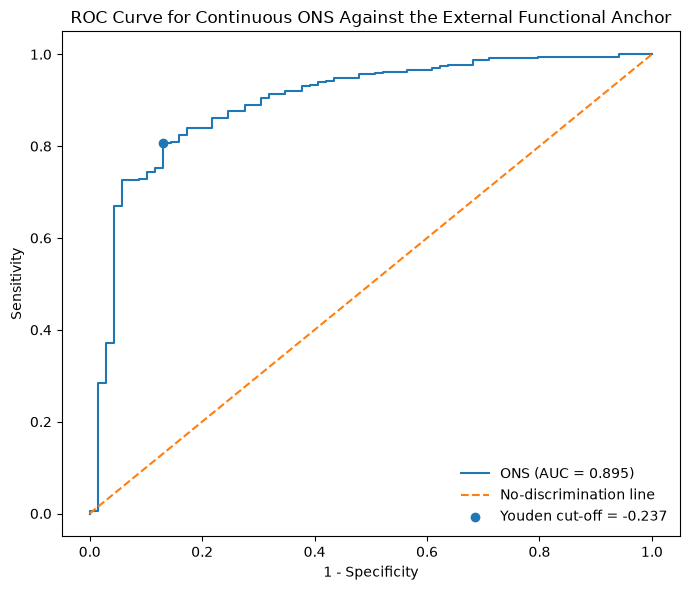

In [12]:
# Figure 4.1 — binary ONS distribution
fig, ax = plt.subplots(figsize=(8, 5))
labels = ["Suboptimal ONS (0)", "Optimal ONS (1)"]
counts = [127, 289]
bars = ax.bar(labels, counts)

for bar, count in zip(bars, counts):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        count + 5,
        f"{count} ({count/len(df)*100:.1f}%)",
        ha="center",
        va="bottom"
    )

ax.set_xlabel("ONS classification")
ax.set_ylabel("Number of participants")
ax.set_title("Distribution of the Primary Binary ONS Outcome")
ax.set_ylim(0, 330)
fig.tight_layout()
print("Saved:", save_figure(fig, "Figure_4_1_Primary_Binary_ONS_Distribution.png"))
plt.show()
plt.close(fig)

# Figure 4.2 — continuous ONS distribution and thresholds
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(ONS, bins=40)
ax.axvline(ONS_cutoff, linestyle="--", label=f"Primary cut-off = {ONS_cutoff:.3f}")
ax.axvline(ONS.median(), linestyle=":", label=f"Median = {ONS.median():.3f}")
ax.axvline(ONS.quantile(2/3), linestyle="-.", label=f"Upper tertile = {ONS.quantile(2/3):.3f}")
ax.set_xlabel("Continuous ONS")
ax.set_ylabel("Number of participants")
ax.set_title("Distribution of Continuous ONS and Candidate Thresholds")
ax.legend(frameon=False)
fig.tight_layout()
print("Saved:", save_figure(fig, "Figure_4_2_Continuous_ONS_Thresholds.png"))
plt.show()
plt.close(fig)

# Figure 4.3 — ROC curve for ONS against external anchor
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, label=f"ONS (AUC = {auc_ons:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", label="No-discrimination line")
ax.scatter(
    fpr[best_idx], tpr[best_idx],
    label=f"Youden cut-off = {ONS_cutoff:.3f}"
)
ax.set_xlabel("1 - Specificity")
ax.set_ylabel("Sensitivity")
ax.set_title("ROC Curve for Continuous ONS Against the External Functional Anchor")
ax.legend(frameon=False)
fig.tight_layout()
print("Saved:", save_figure(fig, "Figure_4_3_ONS_Anchor_ROC.png"))
plt.show()
plt.close(fig)

# PART B — PREDICTOR PREPARATION

The primary predictive outcome is the frozen binary ONS. Variables representing follow-up/change information or the external anchor are excluded from the predictor matrix to prevent outcome leakage.

## B1. Predictor inventory, completeness and structural missingness

In [13]:
primary_predictors = [
    "Study site",
    "Early_rehabilitation",
    "Child sex",
    "Primary cerebral palsy type",
    "Predominantly affected body region",
    "Caregiver highest education level",
    "Household income band",
    "Health insurance available?",
    "Distance to primary rehabilitation facility (km)",
    "Adequate social support reported?",
    "Household experienced food insecurity in past 30 days?",
    "Received rehabilitation before enrolment?",
    "Duration of previous rehabilitation (months)",
    "GMFCS level at baseline",
    "GMFM total score at baseline (%)",
    "VABS overall/composite score at baseline",
    "CPQoL overall score at baseline",
    "Facility therapy adherence (%)",
    "Facility_intensity_primary",
    "Caregiver completed home-program training?",
    "Caregiver adherence to home programme (%)",
    "Caregiver confidence score",
    "Total therapy sessions missed",
    "Longest therapy interruption (days)"
]

# Derive the timing variable once.
model_df = df.copy()
model_df["Early_rehabilitation"] = (
    model_df["Age at first rehabilitation (months)"] < AGE_CUTOFF_MONTHS
).astype(int)

# Preserve original intensity and define the primary version.
intensity_col = "Approximate facility therapy intensity (minutes/week)"
model_df["Facility_intensity_original"] = model_df[intensity_col]
model_df["Facility_intensity_primary"] = model_df[intensity_col].replace(0, np.nan)

# Home-programme missingness indicators.
model_df["Home_adherence_missing"] = (
    model_df["Caregiver adherence to home programme (%)"].isna().astype(int)
)
model_df["Home_confidence_missing"] = (
    model_df["Caregiver confidence score"].isna().astype(int)
)

# Completeness table
missing_audit = pd.DataFrame({
    "Variable": primary_predictors,
    "N": [model_df[c].notna().sum() for c in primary_predictors],
    "Missing": [model_df[c].isna().sum() for c in primary_predictors]
})
missing_audit["Missing (%)"] = 100 * missing_audit["Missing"] / len(model_df)

display(missing_audit.sort_values("Missing (%)", ascending=False).round(1))
save_table(missing_audit, "Table_B1_Primary_Predictor_Completeness.csv")

# Structural home-programme missingness
home_training = model_df["Caregiver completed home-program training?"]
home_missing_table = pd.crosstab(
    home_training.fillna("Missing training status"),
    model_df["Caregiver adherence to home programme (%)"].isna(),
    rownames=["Training status"],
    colnames=["Home adherence missing"]
)
display(home_missing_table)
home_missing_table.to_csv(TABLE_DIR / "Table_B2_Home_Programme_Missingness.csv")

# Timing verification
timing_check = pd.crosstab(
    df["Age group at first rehabilitation"],
    model_df["Early_rehabilitation"].map({0: "Later (>=24 months)", 1: "Early (<24 months)"}),
    dropna=False
)
display(timing_check)
timing_check.to_csv(TABLE_DIR / "Table_B3_Rehabilitation_Timing_Check.csv")

print("Important: recorded home adherence is retained as recorded; it is not overwritten using reconstructed session counts.")

,Variable,N,Missing,Missing (%)
20,Caregiver adherence to home programme (%),293,123,29.600
21,Caregiver confidence score,294,122,29.300
5,Caregiver highest education level,402,14,3.400
18,Facility_intensity_primary,402,14,3.400
6,Household income band,409,7,1.700
19,Caregiver completed home-program training?,411,5,1.200
23,Longest therapy interruption (days),415,1,0.200
12,Duration of previous rehabilitation (months),415,1,0.200
7,Health insurance available?,416,0,0.000
4,Predominantly affected body region,416,0,0.000


Home adherence missing,False,True
Training status,,
Missing training status,0,5
No,27,117
Yes,266,1


Early_rehabilitation,Early (<24 months),Later (>=24 months)
Age group at first rehabilitation,,
2_years_or_older,0,244
before_2_years,172,0


Important: recorded home adherence is retained as recorded; it is not overwritten using reconstructed session counts.


## B2. Numerical correlations and treatment-exposure redundancy

,Variable 1,Variable 2,Pearson r,Absolute |r|
0,GMFM total score at baseline (%),VABS overall/composite score at baseline,0.840,0.840


Correlation between missed sessions and longest interruption: 0.104
Saved: C:\Users\hp\Documents\MSc_Thesis_Analysis\06_Figures\Figure_4_4_Numerical_Predictor_Correlation_Matrix.png


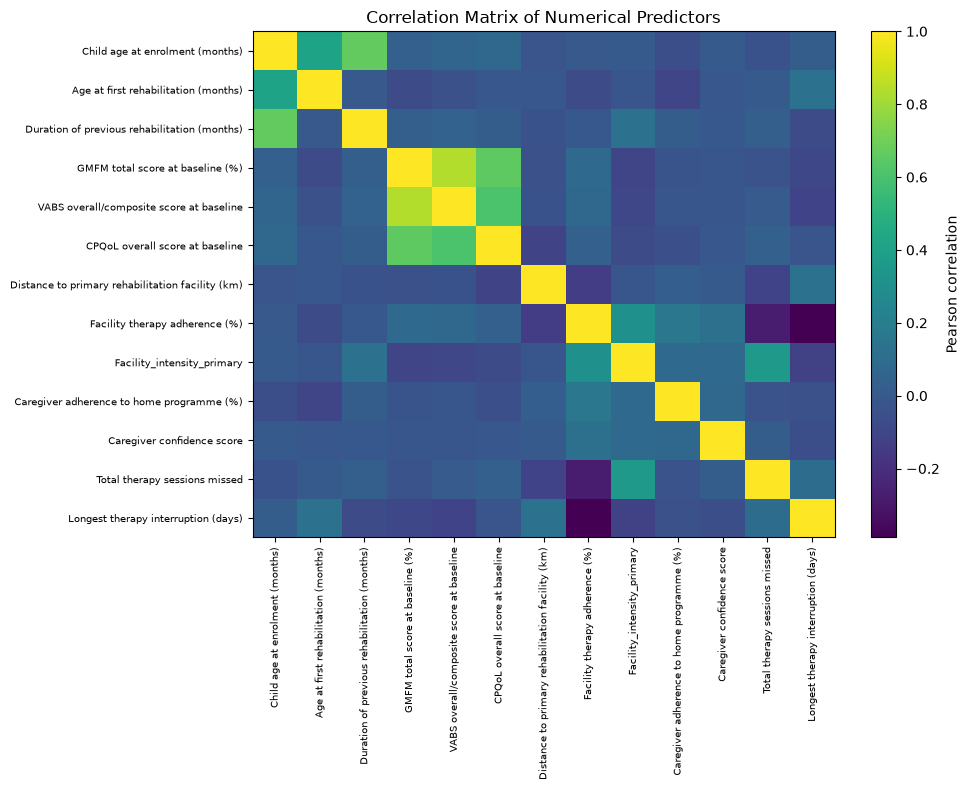

In [14]:
numeric_for_corr = [
    "Child age at enrolment (months)",
    "Age at first rehabilitation (months)",
    "Duration of previous rehabilitation (months)",
    "GMFM total score at baseline (%)",
    "VABS overall/composite score at baseline",
    "CPQoL overall score at baseline",
    "Distance to primary rehabilitation facility (km)",
    "Facility therapy adherence (%)",
    "Facility_intensity_primary",
    "Caregiver adherence to home programme (%)",
    "Caregiver confidence score",
    "Total therapy sessions missed",
    "Longest therapy interruption (days)"
]

corr_matrix = model_df[numeric_for_corr].corr()

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) >= 0.70:
            high_corr_pairs.append({
                "Variable 1": corr_matrix.columns[i],
                "Variable 2": corr_matrix.columns[j],
                "Pearson r": r,
                "Absolute |r|": abs(r)
            })

high_corr_pairs = pd.DataFrame(high_corr_pairs).sort_values(
    "Absolute |r|", ascending=False
)

display(high_corr_pairs.round(3))
save_table(high_corr_pairs, "Table_B4_High_Correlation_Predictor_Pairs.csv")

# Treatment interruption relationship
interruption_corr = model_df[
    ["Total therapy sessions missed", "Longest therapy interruption (days)"]
].corr().iloc[0, 1]

print(f"Correlation between missed sessions and longest interruption: {interruption_corr:.3f}")

# Heatmap-style matrix using matplotlib (no fixed colours)
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix, aspect="auto")
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_xticklabels(corr_matrix.columns, rotation=90, fontsize=7)
ax.set_yticklabels(corr_matrix.index, fontsize=7)
fig.colorbar(im, ax=ax, label="Pearson correlation")
ax.set_title("Correlation Matrix of Numerical Predictors")
fig.tight_layout()
print("Saved:", save_figure(fig, "Figure_4_4_Numerical_Predictor_Correlation_Matrix.png"))
plt.show()
plt.close(fig)

## B3. Assemble the primary modelling dataframe and verify leakage

In [15]:
model_data = model_df[
    ["Participant Study ID", "ONS_binary"] + primary_predictors
].copy()

# Add the two structural missingness indicators once, here.
model_data["Home_adherence_missing"] = (
    model_data["Caregiver adherence to home programme (%)"].isna().astype(int)
)
model_data["Home_confidence_missing"] = (
    model_data["Caregiver confidence score"].isna().astype(int)
)

leakage_keywords = [
    "follow-up", "change", "percentage change",
    "Functional Improvement Index",
    "Functional goals achieved?",
    "Overall clinical improvement observed?",
    "ONS_continuous", "ONS_binary"
]

detected_leakage = [
    (col, keyword)
    for col in primary_predictors
    for keyword in leakage_keywords
    if keyword.lower() in col.lower()
]

assert not detected_leakage, f"Potential leakage detected: {detected_leakage}"

print("Model dataframe shape:", model_data.shape)
print("Outcome distribution:")
display(
    model_data["ONS_binary"].value_counts()
    .sort_index()
    .rename(index={0: "Suboptimal ONS", 1: "Optimal ONS"})
    .to_frame("Count")
)

model_missing = model_data.isna().sum().to_frame("Missing")
model_missing["Missing (%)"] = 100 * model_missing["Missing"] / len(model_data)
display(model_missing[model_missing["Missing"] > 0].sort_values("Missing", ascending=False).round(1))
save_table(
    model_missing.reset_index().rename(columns={"index": "Variable"}),
    "Table_B5_Modelling_Data_Missingness.csv"
)

Model dataframe shape: (416, 28)
Outcome distribution:


,Count
ONS_binary,
Suboptimal ONS,127
Optimal ONS,289


,Missing,Missing (%)
Caregiver adherence to home programme (%),123,29.600
Caregiver confidence score,122,29.300
Caregiver highest education level,14,3.400
Facility_intensity_primary,14,3.400
Household income band,7,1.700
Caregiver completed home-program training?,5,1.200
Duration of previous rehabilitation (months),1,0.200
Longest therapy interruption (days),1,0.200


WindowsPath('C:/Users/hp/Documents/MSc_Thesis_Analysis/07_Tables/Table_B5_Modelling_Data_Missingness.csv')

## B4. Define predictor types and preprocessing

In [16]:
categorical_features = [
    "Study site",
    "Child sex",
    "Primary cerebral palsy type",
    "Predominantly affected body region",
    "Received rehabilitation before enrolment?",
    "GMFCS level at baseline",
    "Caregiver highest education level",
    "Household income band",
    "Health insurance available?",
    "Adequate social support reported?",
    "Household experienced food insecurity in past 30 days?",
    "Caregiver completed home-program training?"
]

numeric_features = [
    "Early_rehabilitation",
    "Duration of previous rehabilitation (months)",
    "GMFM total score at baseline (%)",
    "VABS overall/composite score at baseline",
    "CPQoL overall score at baseline",
    "Distance to primary rehabilitation facility (km)",
    "Facility therapy adherence (%)",
    "Facility_intensity_primary",
    "Caregiver adherence to home programme (%)",
    "Caregiver confidence score",
    "Total therapy sessions missed",
    "Longest therapy interruption (days)",
    "Home_adherence_missing",
    "Home_confidence_missing"
]

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("categorical", categorical_pipeline, categorical_features),
    ("numeric", numeric_pipeline, numeric_features)
])

X = model_data[categorical_features + numeric_features].copy()
y = model_data["ONS_binary"].astype(int).copy()

print("Categorical predictors:", len(categorical_features))
print("Numeric predictors:", len(numeric_features))
print("Total raw predictor columns:", X.shape[1])
print("Outcome prevalence:", f"{y.mean()*100:.1f}%")

Categorical predictors: 12
Numeric predictors: 14
Total raw predictor columns: 26
Outcome prevalence: 69.5%


# PART C — PRIMARY ELASTIC-NET LOGISTIC REGRESSION

The primary predictive model uses elastic-net logistic regression with nested stratified cross-validation. The model is evaluated using AUC, Brier score, log-loss and calibration.

## C1. Elastic-net model specification

In [17]:
elastic_net = LogisticRegression(
    solver="saga",
    l1_ratio=0.5,
    max_iter=5000,
    random_state=RANDOM_STATE
)

param_grid = {
    "model__C": np.logspace(-2, 1, 10),
    "model__l1_ratio": [0.2, 0.5, 0.8]
}

model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", elastic_net)
])

inner_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

outer_cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=3,
    random_state=RANDOM_STATE
)

print("Elastic-net configured.")
print("Inner CV: 5-fold stratified")
print("Outer CV: 5-fold stratified × 3 repetitions")
print("Grid: 10 C values × 3 L1 ratios")

Elastic-net configured.
Inner CV: 5-fold stratified
Outer CV: 5-fold stratified × 3 repetitions
Grid: 10 C values × 3 L1 ratios


## C2. Nested cross-validation

In [18]:
# ============================================================
# C2. NESTED CROSS-VALIDATION
# ============================================================

# Create modelling copies
X_cv = X.copy()
y_cv = pd.to_numeric(y, errors="raise").astype(int)

# ------------------------------------------------------------
# 1. Make missing values compatible with scikit-learn
# ------------------------------------------------------------

# Categorical variables:
# - convert pandas StringDtype/category columns to ordinary objects
# - replace pd.NA with np.nan
for column in categorical_features:
    X_cv[column] = X_cv[column].astype(object)
    X_cv[column] = X_cv[column].where(
        X_cv[column].notna(),
        np.nan
    )

# Numerical variables:
# - force values to numeric
# - invalid values become np.nan
for column in numeric_features:
    X_cv[column] = pd.to_numeric(
        X_cv[column],
        errors="coerce"
    ).astype(float)

# ------------------------------------------------------------
# 2. Validate the modelling data
# ------------------------------------------------------------

if y_cv.isna().any():
    raise ValueError(
        "ONS_binary contains missing values. "
        "The outcome must be complete before modelling."
    )

if y_cv.nunique() != 2:
    raise ValueError(
        f"ONS_binary must contain exactly two classes, "
        f"but {y_cv.nunique()} classes were found."
    )

unexpected_columns = (
    set(categorical_features + numeric_features) -
    set(X_cv.columns)
)

if unexpected_columns:
    raise KeyError(
        f"These predictor columns are missing: "
        f"{sorted(unexpected_columns)}"
    )

print("Nested cross-validation data prepared.")
print("Participants:", len(X_cv))
print("Predictors:", X_cv.shape[1])
print("Outcome classes:", sorted(y_cv.unique()))
print("Missing predictor values:", int(X_cv.isna().sum().sum()))

# ------------------------------------------------------------
# 3. Run nested cross-validation
# ------------------------------------------------------------

nested_results = []
nested_oof_records = []

for outer_evaluation, (train_idx, test_idx) in enumerate(
    outer_cv.split(X_cv, y_cv),
    start=1
):
    X_train = X_cv.iloc[train_idx].copy()
    X_test = X_cv.iloc[test_idx].copy()

    y_train = y_cv.iloc[train_idx].copy()
    y_test = y_cv.iloc[test_idx].copy()

    search = GridSearchCV(
        estimator=model_pipeline,
        param_grid=param_grid,
        scoring="neg_log_loss",
        cv=inner_cv,
        n_jobs=-1,
        refit=True,
        error_score="raise"
    )

    search.fit(X_train, y_train)

    predicted_probability = search.predict_proba(X_test)[:, 1]

    # Prevent log(0) when calculating log-loss manually
    probability_clipped = np.clip(
        predicted_probability,
        1e-12,
        1 - 1e-12
    )

    fold_log_loss = -np.mean(
        y_test.to_numpy() * np.log(probability_clipped) +
        (1 - y_test.to_numpy()) *
        np.log(1 - probability_clipped)
    )

    nested_results.append({
        "Outer evaluation": outer_evaluation,
        "AUC": roc_auc_score(
            y_test,
            predicted_probability
        ),
        "Brier": brier_score_loss(
            y_test,
            predicted_probability
        ),
        "Log-loss": fold_log_loss,
        "C": search.best_params_["model__C"],
        "L1 ratio": search.best_params_["model__l1_ratio"]
    })

    nested_oof_records.append(
        pd.DataFrame({
            "Participant_Index": X_test.index,
            "Outer_evaluation": outer_evaluation,
            "Observed": y_test.to_numpy(),
            "Predicted_probability": predicted_probability
        })
    )

    print(
        f"Completed outer evaluation "
        f"{outer_evaluation}"
    )

# ------------------------------------------------------------
# 4. Combine the nested cross-validation results
# ------------------------------------------------------------

if not nested_results:
    raise RuntimeError(
        "Nested cross-validation produced no results."
    )

nested_results_df = pd.DataFrame(nested_results)

nested_oof = pd.concat(
    nested_oof_records,
    ignore_index=True
)

# ------------------------------------------------------------
# 5. Summarise model performance
# ------------------------------------------------------------

performance_summary = pd.DataFrame({
    "Metric": [
        "AUC",
        "Brier score",
        "Log-loss"
    ],
    "Mean": [
        nested_results_df["AUC"].mean(),
        nested_results_df["Brier"].mean(),
        nested_results_df["Log-loss"].mean()
    ],
    "SD": [
        nested_results_df["AUC"].std(ddof=1),
        nested_results_df["Brier"].std(ddof=1),
        nested_results_df["Log-loss"].std(ddof=1)
    ],
    "Minimum": [
        nested_results_df["AUC"].min(),
        nested_results_df["Brier"].min(),
        nested_results_df["Log-loss"].min()
    ],
    "Maximum": [
        nested_results_df["AUC"].max(),
        nested_results_df["Brier"].max(),
        nested_results_df["Log-loss"].max()
    ]
}).round(3)

display(performance_summary)

save_table(
    performance_summary,
    "Table_C1_Nested_CV_Performance.csv"
)

save_result(
    performance_summary,
    "ElasticNet_Performance_Summary.csv"
)

save_result(
    nested_results_df,
    "ElasticNet_Outer_Fold_Results.csv"
)

save_result(
    nested_oof,
    "ElasticNet_Out_of_Fold_Predictions.csv"
)

print(
    f"\nNested cross-validation completed successfully."
)
print(
    f"Outer-fold evaluations: "
    f"{len(nested_results_df)}"
)
print(
    f"Out-of-fold prediction records: "
    f"{len(nested_oof)}"
)

Nested cross-validation data prepared.
Participants: 416
Predictors: 26
Outcome classes: [np.int64(0), np.int64(1)]
Missing predictor values: 287
Completed outer evaluation 1
Completed outer evaluation 2
Completed outer evaluation 3
Completed outer evaluation 4
Completed outer evaluation 5
Completed outer evaluation 6
Completed outer evaluation 7
Completed outer evaluation 8
Completed outer evaluation 9
Completed outer evaluation 10
Completed outer evaluation 11
Completed outer evaluation 12
Completed outer evaluation 13
Completed outer evaluation 14
Completed outer evaluation 15


,Metric,Mean,SD,Minimum,Maximum
0,AUC,0.868,0.024,0.816,0.912
1,Brier score,0.134,0.014,0.108,0.161
2,Log-loss,0.419,0.038,0.352,0.482



Nested cross-validation completed successfully.
Outer-fold evaluations: 15
Out-of-fold prediction records: 1248


## C3. Participant-level calibration

,Measure,Estimate,95% CI lower,95% CI upper
0,Calibration intercept,-0.031,-0.319,0.258
1,Calibration slope,1.048,0.831,1.266


Saved: C:\Users\hp\Documents\MSc_Thesis_Analysis\06_Figures\Figure_4_5_ElasticNet_Calibration.png


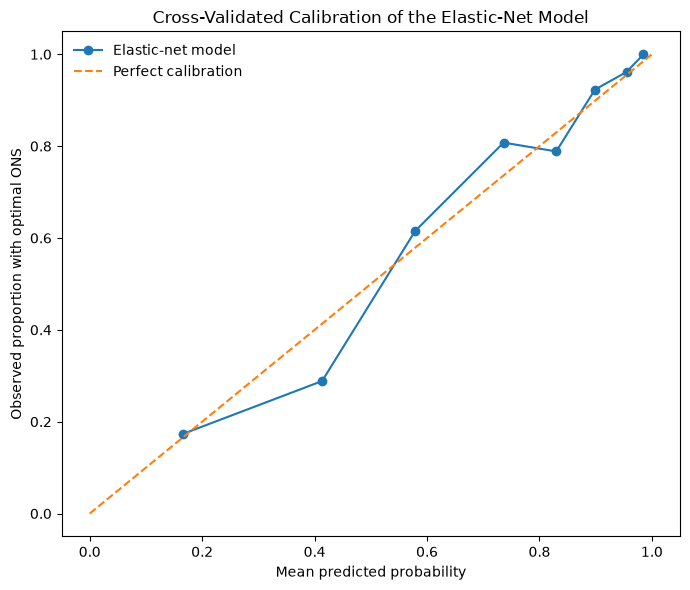

In [19]:
calibration_summary = (
    nested_oof
    .groupby("Participant_Index", as_index=False)
    .agg(
        Observed=("Observed", "first"),
        Predicted_probability=("Predicted_probability", "mean")
    )
)

observed = calibration_summary["Observed"].to_numpy()
probability = np.clip(
    calibration_summary["Predicted_probability"].to_numpy(),
    1e-6, 1 - 1e-6
)

logit_probability = np.log(probability / (1 - probability))

X_cal = sm.add_constant(logit_probability)
calibration_fit = sm.GLM(
    observed,
    X_cal,
    family=sm.families.Binomial()
).fit()

calibration_intercept = calibration_fit.params[0]
calibration_slope = calibration_fit.params[1]
ci = calibration_fit.conf_int()

calibration_table = pd.DataFrame({
    "Measure": ["Calibration intercept", "Calibration slope"],
    "Estimate": [calibration_intercept, calibration_slope],
    "95% CI lower": [ci[0, 0], ci[1, 0]],
    "95% CI upper": [ci[0, 1], ci[1, 1]]
}).round(3)

display(calibration_table)
save_table(calibration_table, "Table_C2_Calibration_Assessment.csv")
save_result(calibration_table, "ElasticNet_Calibration_Results.csv")
save_result(calibration_summary, "ElasticNet_Calibration_Predictions.csv")

fraction_positive, mean_predicted = calibration_curve(
    observed,
    probability,
    n_bins=8,
    strategy="quantile"
)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(mean_predicted, fraction_positive, marker="o", label="Elastic-net model")
ax.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed proportion with optimal ONS")
ax.set_title("Cross-Validated Calibration of the Elastic-Net Model")
ax.legend(frameon=False)
fig.tight_layout()
print("Saved:", save_figure(fig, "Figure_4_5_ElasticNet_Calibration.png"))
plt.show()
plt.close(fig)

## C4. Final hyperparameter selection and coefficient table

In [20]:
# ============================================================
# C4. FINAL ELASTIC-NET MODEL AND COEFFICIENT TABLE
# ============================================================

# Create independent copies for final model fitting
X_final = X.copy()
y_final = pd.to_numeric(
    y,
    errors="raise"
).astype(int)

# ------------------------------------------------------------
# 1. Prepare categorical predictors
# ------------------------------------------------------------

# Convert categorical columns to ordinary object dtype and
# replace pandas pd.NA values with NumPy np.nan.
for column in categorical_features:
    X_final[column] = X_final[column].astype(object)

    X_final[column] = X_final[column].map(
        lambda value: np.nan if pd.isna(value) else value
    )

# ------------------------------------------------------------
# 2. Prepare numerical predictors
# ------------------------------------------------------------

# Force numerical predictors to numeric.
# Invalid entries become np.nan and will be median-imputed.
for column in numeric_features:
    X_final[column] = pd.to_numeric(
        X_final[column],
        errors="coerce"
    ).astype(float)

# ------------------------------------------------------------
# 3. Validate the final modelling data
# ------------------------------------------------------------

missing_predictors = (
    set(categorical_features + numeric_features)
    - set(X_final.columns)
)

if missing_predictors:
    raise KeyError(
        "The following predictors are missing: "
        f"{sorted(missing_predictors)}"
    )

if y_final.isna().any():
    raise ValueError(
        "The outcome variable contains missing values."
    )

if y_final.nunique() != 2:
    raise ValueError(
        "The outcome variable must contain exactly two classes. "
        f"Found: {sorted(y_final.unique())}"
    )

print("Final modelling data prepared.")
print("Participants:", X_final.shape[0])
print("Predictors:", X_final.shape[1])
print("Outcome classes:", sorted(y_final.unique()))
print(
    "Missing predictor values before pipeline imputation:",
    int(X_final.isna().sum().sum())
)

# ------------------------------------------------------------
# 4. Select the final elastic-net hyperparameters
# ------------------------------------------------------------

final_search = GridSearchCV(
    estimator=model_pipeline,
    param_grid=param_grid,
    scoring="neg_log_loss",
    cv=inner_cv,
    n_jobs=-1,
    refit=True,
    return_train_score=True,
    error_score="raise"
)

final_search.fit(X_final, y_final)

# ------------------------------------------------------------
# 5. Extract the best model
# ------------------------------------------------------------

best_C = final_search.best_params_["model__C"]
best_l1_ratio = final_search.best_params_["model__l1_ratio"]

best_pipeline = final_search.best_estimator_

final_preprocessor = best_pipeline.named_steps["preprocessor"]
final_model = best_pipeline.named_steps["model"]

# ------------------------------------------------------------
# 6. Extract encoded feature names and coefficients
# ------------------------------------------------------------

feature_names = final_preprocessor.get_feature_names_out()
coefficients = final_model.coef_.ravel()

if len(feature_names) != len(coefficients):
    raise ValueError(
        "The number of encoded feature names does not match "
        "the number of model coefficients."
    )

coef_table = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Remove ColumnTransformer prefixes for clearer presentation
coef_table["Feature"] = (
    coef_table["Feature"]
    .str.replace("categorical__", "", regex=False)
    .str.replace("numeric__", "", regex=False)
)

# Calculate odds ratios
coef_table["Odds_Ratio"] = np.exp(
    np.clip(coef_table["Coefficient"], -700, 700)
)

# Identify variables retained by elastic-net regularisation
coef_table["Absolute_Coefficient"] = (
    coef_table["Coefficient"].abs()
)

coef_table["Selected"] = ~np.isclose(
    coef_table["Coefficient"],
    0.0,
    atol=1e-12
)

# Sort predictors from strongest to weakest coefficient
coef_table = (
    coef_table
    .sort_values(
        "Absolute_Coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 7. Display and save the coefficient table
# ------------------------------------------------------------

coefficient_output = coef_table[
    [
        "Feature",
        "Coefficient",
        "Odds_Ratio",
        "Selected"
    ]
].copy()

display(coefficient_output.round(3))

save_table(
    coefficient_output.round(4),
    "Table_C3_Final_ElasticNet_Coefficients.csv"
)

save_result(
    coefficient_output.round(6),
    "Final_ElasticNet_Coefficients.csv"
)

# ------------------------------------------------------------
# 8. Report the selected model
# ------------------------------------------------------------

best_log_loss = -final_search.best_score_
number_selected = int(coef_table["Selected"].sum())
number_zero = int((~coef_table["Selected"]).sum())

final_model_summary = pd.DataFrame({
    "Measure": [
        "Best C",
        "Best L1 ratio",
        "Best inner-CV log-loss",
        "Encoded features",
        "Non-zero coefficients",
        "Zero coefficients"
    ],
    "Value": [
        best_C,
        best_l1_ratio,
        best_log_loss,
        len(coef_table),
        number_selected,
        number_zero
    ]
})

save_result(
    final_model_summary,
    "Final_ElasticNet_Model_Summary.csv"
)

print("\nFinal elastic-net model fitted successfully.")
print(f"Best C: {best_C:.3f}")
print(f"Best L1 ratio: {best_l1_ratio:.3f}")
print(f"Best inner-CV log-loss: {best_log_loss:.3f}")
print(f"Encoded features: {len(coef_table)}")
print(f"Non-zero coefficients: {number_selected}")
print(f"Zero coefficients: {number_zero}")


Final modelling data prepared.
Participants: 416
Predictors: 26
Outcome classes: [np.int64(0), np.int64(1)]
Missing predictor values before pipeline imputation: 287


,Feature,Coefficient,Odds_Ratio,Selected
0,GMFCS level at baseline_Level V,1.222,3.393,True
1,Early_rehabilitation,1.101,3.007,True
2,GMFCS level at baseline_Level IV,0.964,2.622,True
3,Facility therapy adherence (%),0.899,2.458,True
4,GMFCS level at baseline_Level III,0.723,2.060,True
5,GMFM total score at baseline (%),0.656,1.926,True
6,Home_adherence_missing,-0.649,0.523,True
7,Household experienced food insecurity in past ...,0.531,1.701,True
8,Facility_intensity_primary,0.434,1.543,True
9,Primary cerebral palsy type_Mixed,0.427,1.532,True



Final elastic-net model fitted successfully.
Best C: 0.464
Best L1 ratio: 0.500
Best inner-CV log-loss: 0.417
Encoded features: 44
Non-zero coefficients: 32
Zero coefficients: 12


In [21]:
## C5. Verify categorical reference categories
encoder = (
    final_preprocessor
    .named_transformers_["categorical"]
    .named_steps["onehot"]
)

reference_table = pd.DataFrame({
    "Variable": categorical_features,
    "Reference category": [cats[0] for cats in encoder.categories_]
})

display(reference_table)
save_table(reference_table, "Table_C4_Categorical_Reference_Categories.csv")

,Variable,Reference category
0,Study site,ACK North Rift Rehabilitation Centre
1,Child sex,Female
2,Primary cerebral palsy type,Ataxic
3,Predominantly affected body region,Bilateral lower-limb predominant
4,Received rehabilitation before enrolment?,No
5,GMFCS level at baseline,Level I
6,Caregiver highest education level,Certificate/Diploma
7,Household income band,"Below KES 10,000"
8,Health insurance available?,No
9,Adequate social support reported?,No


WindowsPath('C:/Users/hp/Documents/MSc_Thesis_Analysis/07_Tables/Table_C4_Categorical_Reference_Categories.csv')

## C6. Bootstrap coefficient stability

Bootstrap data prepared.
Participants: 416
Encoded predictors: 44
Bootstrap repetitions: 300
Completed 50 of 300 bootstrap repetitions.
Completed 100 of 300 bootstrap repetitions.
Completed 150 of 300 bootstrap repetitions.
Completed 200 of 300 bootstrap repetitions.
Completed 250 of 300 bootstrap repetitions.
Completed 300 of 300 bootstrap repetitions.


,Feature,Original coefficient,Bootstrap median,Bootstrap 2.5%,Bootstrap 97.5%,Selection frequency,Positive frequency,Negative frequency,OR,OR 2.5%,OR 97.5%
0,GMFCS level at baseline_Level V,1.222,1.181,0.515,1.875,1.000,1.000,0.000,3.393,1.674,6.519
1,Early_rehabilitation,1.101,1.183,0.893,1.508,1.000,1.000,0.000,3.007,2.444,4.519
2,GMFCS level at baseline_Level IV,0.964,0.932,0.296,1.558,1.000,1.000,0.000,2.622,1.345,4.748
3,Facility therapy adherence (%),0.899,0.957,0.535,1.514,1.000,1.000,0.000,2.458,1.708,4.546
4,Home_adherence_missing,-0.649,-0.591,-0.957,-0.271,1.000,0.000,1.000,0.523,0.384,0.763
5,GMFM total score at baseline (%),0.656,0.716,0.272,1.127,0.997,0.997,0.000,1.926,1.313,3.086
6,GMFCS level at baseline_Level III,0.723,0.671,0.099,1.259,0.990,0.983,0.007,2.060,1.104,3.522
7,Caregiver adherence to home programme (%),0.317,0.345,0.057,0.634,0.990,0.987,0.003,1.373,1.058,1.885
8,Facility_intensity_primary,0.434,0.425,0.071,0.778,0.987,0.987,0.000,1.543,1.073,2.178
9,Distance to primary rehabilitation facility (km),0.319,0.361,0.000,0.692,0.973,0.967,0.007,1.375,1.000,1.997


Saved: C:\Users\hp\Documents\MSc_Thesis_Analysis\06_Figures\Figure_4_6_ElasticNet_Coefficient_Stability.png


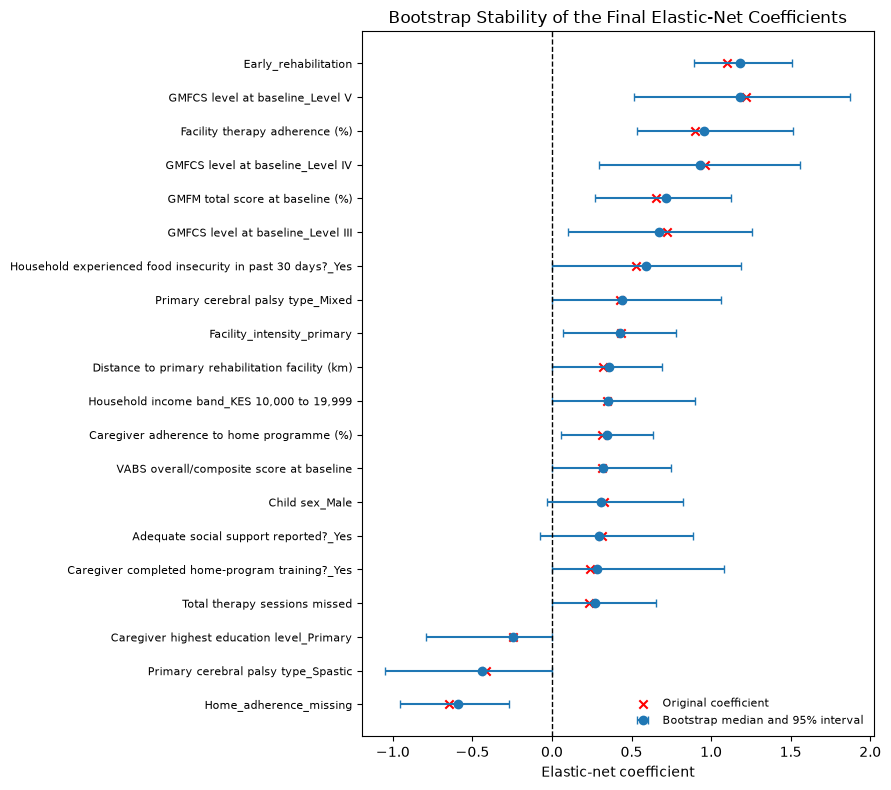


Bootstrap analysis completed.
Requested repetitions: 300
Successful repetitions: 300
Failed repetitions: 0
Success rate: 100.0%


WindowsPath('C:/Users/hp/Documents/MSc_Thesis_Analysis/05_Results/ElasticNet_Bootstrap_Run_Summary.csv')

In [22]:
# ============================================================
# C6. BOOTSTRAP STABILITY OF ELASTIC-NET COEFFICIENTS
# ============================================================

rng = np.random.default_rng(RANDOM_STATE)

# ------------------------------------------------------------
# 1. Confirm that the final-model objects are available
# ------------------------------------------------------------

required_objects = [
    "X_final",
    "y_final",
    "final_preprocessor",
    "final_model",
    "feature_names",
    "coefficients",
    "best_C",
    "best_l1_ratio"
]

missing_objects = [
    name for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise NameError(
        "Run the corrected final elastic-net model cell first. "
        f"Missing objects: {missing_objects}"
    )

# ------------------------------------------------------------
# 2. Transform the predictors using the fitted preprocessor
# ------------------------------------------------------------

# The fitted preprocessor performs:
# - categorical imputation
# - one-hot encoding
# - numerical imputation
# - numerical standardisation
X_transformed = final_preprocessor.transform(X_final)

y_bootstrap = np.asarray(y_final, dtype=int)

# Confirm that the transformed features match the coefficients
if X_transformed.shape[1] != len(feature_names):
    raise ValueError(
        "The number of transformed predictors does not match "
        "the number of feature names."
    )

if len(coefficients) != len(feature_names):
    raise ValueError(
        "The number of original coefficients does not match "
        "the number of feature names."
    )

print("Bootstrap data prepared.")
print("Participants:", X_transformed.shape[0])
print("Encoded predictors:", X_transformed.shape[1])
print("Bootstrap repetitions:", N_BOOTSTRAP)

# ------------------------------------------------------------
# 3. Create stratified bootstrap samples
# ------------------------------------------------------------

# Separate the indices for the two outcome classes.
# Sampling each class separately ensures every bootstrap sample
# contains both outcome classes.
class_0_indices = np.flatnonzero(y_bootstrap == 0)
class_1_indices = np.flatnonzero(y_bootstrap == 1)

if len(class_0_indices) == 0 or len(class_1_indices) == 0:
    raise ValueError(
        "Both outcome classes are required for bootstrapping."
    )

bootstrap_coefficients = np.full(
    shape=(N_BOOTSTRAP, len(feature_names)),
    fill_value=np.nan,
    dtype=float
)

successful_bootstraps = 0
failed_bootstraps = 0

# ------------------------------------------------------------
# 4. Fit the elastic-net model in each bootstrap sample
# ------------------------------------------------------------

for bootstrap_number in range(N_BOOTSTRAP):

    # Sample with replacement within each outcome class
    sampled_class_0 = rng.choice(
        class_0_indices,
        size=len(class_0_indices),
        replace=True
    )

    sampled_class_1 = rng.choice(
        class_1_indices,
        size=len(class_1_indices),
        replace=True
    )

    bootstrap_indices = np.concatenate([
        sampled_class_0,
        sampled_class_1
    ])

    # Randomise the order of sampled observations
    rng.shuffle(bootstrap_indices)

    X_sample = X_transformed[bootstrap_indices]
    y_sample = y_bootstrap[bootstrap_indices]

    # Clone only the fitted model specification.
    # The predictors have already been preprocessed.
    fitted_model = clone(final_model)

    try:
        fitted_model.fit(X_sample, y_sample)

        fitted_coefficients = fitted_model.coef_.ravel()

        if len(fitted_coefficients) != len(feature_names):
            raise ValueError(
                "Bootstrap coefficient count does not match "
                "the encoded feature count."
            )

        bootstrap_coefficients[
            bootstrap_number, :
        ] = fitted_coefficients

        successful_bootstraps += 1

    except Exception as error:
        failed_bootstraps += 1
        print(
            f"Bootstrap {bootstrap_number + 1} failed: "
            f"{type(error).__name__}: {error}"
        )

    # Display progress after every 50 repetitions
    if (
        (bootstrap_number + 1) % 50 == 0
        or bootstrap_number + 1 == N_BOOTSTRAP
    ):
        print(
            f"Completed {bootstrap_number + 1} "
            f"of {N_BOOTSTRAP} bootstrap repetitions."
        )

# ------------------------------------------------------------
# 5. Retain successful bootstrap estimates
# ------------------------------------------------------------

successful_rows = ~np.isnan(
    bootstrap_coefficients
).all(axis=1)

bootstrap_coefficients_valid = (
    bootstrap_coefficients[successful_rows]
)

if len(bootstrap_coefficients_valid) == 0:
    raise RuntimeError(
        "No bootstrap model was fitted successfully."
    )

coef_bootstrap = pd.DataFrame(
    bootstrap_coefficients_valid,
    columns=feature_names
)

# ------------------------------------------------------------
# 6. Calculate bootstrap stability statistics
# ------------------------------------------------------------

bootstrap_summary = pd.DataFrame({
    "Feature": feature_names,
    "Original coefficient": coefficients,
    "Bootstrap median": (
        coef_bootstrap.median(axis=0).to_numpy()
    ),
    "Bootstrap 2.5%": (
        coef_bootstrap.quantile(0.025, axis=0).to_numpy()
    ),
    "Bootstrap 97.5%": (
        coef_bootstrap.quantile(0.975, axis=0).to_numpy()
    ),
    "Selection frequency": (
        (coef_bootstrap.abs() > 1e-8)
        .mean(axis=0)
        .to_numpy()
    ),
    "Positive frequency": (
        (coef_bootstrap > 1e-8)
        .mean(axis=0)
        .to_numpy()
    ),
    "Negative frequency": (
        (coef_bootstrap < -1e-8)
        .mean(axis=0)
        .to_numpy()
    )
})

# Remove ColumnTransformer prefixes for presentation
bootstrap_summary["Feature"] = (
    bootstrap_summary["Feature"]
    .str.replace("categorical__", "", regex=False)
    .str.replace("numeric__", "", regex=False)
)

# Use clipping to prevent numerical overflow in exponentiation
bootstrap_summary["OR"] = np.exp(
    np.clip(
        bootstrap_summary["Original coefficient"],
        -700,
        700
    )
)

bootstrap_summary["OR 2.5%"] = np.exp(
    np.clip(
        bootstrap_summary["Bootstrap 2.5%"],
        -700,
        700
    )
)

bootstrap_summary["OR 97.5%"] = np.exp(
    np.clip(
        bootstrap_summary["Bootstrap 97.5%"],
        -700,
        700
    )
)

bootstrap_summary = (
    bootstrap_summary
    .sort_values(
        ["Selection frequency", "Original coefficient"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 7. Display and save the bootstrap table
# ------------------------------------------------------------

display(bootstrap_summary.round(3))

save_table(
    bootstrap_summary.round(4),
    "Table_C5_ElasticNet_Bootstrap_Stability.csv"
)
save_result(
    bootstrap_summary.round(6),
    "ElasticNet_Bootstrap_Stability_Results.csv"
)

# ------------------------------------------------------------
# 8. Plot the 20 strongest coefficients
# ------------------------------------------------------------

plot_df = (
    bootstrap_summary
    .assign(
        Absolute_coefficient=lambda data:
            data["Original coefficient"].abs()
    )
    .nlargest(20, "Absolute_coefficient")
    .sort_values("Bootstrap median")
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(9, 8))

y_positions = np.arange(len(plot_df))

median_values = (
    plot_df["Bootstrap median"].to_numpy()
)

lower_limits = (
    plot_df["Bootstrap 2.5%"].to_numpy()
)

upper_limits = (
    plot_df["Bootstrap 97.5%"].to_numpy()
)

# Error-bar distances must be non-negative
lower_errors = np.maximum(
    median_values - lower_limits,
    0
)

upper_errors = np.maximum(
    upper_limits - median_values,
    0
)

ax.errorbar(
    median_values,
    y_positions,
    xerr=[
        lower_errors,
        upper_errors
    ],
    fmt="o",
    capsize=3,
    label="Bootstrap median and 95% interval"
)

# Show original full-sample coefficient separately
ax.scatter(
    plot_df["Original coefficient"],
    y_positions,
    marker="x",
    color="red",
    label="Original coefficient"
)

ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

ax.set_yticks(y_positions)

ax.set_yticklabels(
    plot_df["Feature"],
    fontsize=8
)

ax.set_xlabel(
    "Elastic-net coefficient"
)

ax.set_title(
    "Bootstrap Stability of the Final Elastic-Net Coefficients"
)

ax.legend(
    frameon=False,
    fontsize=8
)

fig.tight_layout()

figure_path = save_figure(
    fig,
    "Figure_4_6_ElasticNet_Coefficient_Stability.png"
)

print("Saved:", figure_path)

plt.show()
plt.close(fig)

# ------------------------------------------------------------
# 9. Bootstrap completion report
# ------------------------------------------------------------

print("\nBootstrap analysis completed.")
print(f"Requested repetitions: {N_BOOTSTRAP}")
print(f"Successful repetitions: {successful_bootstraps}")
print(f"Failed repetitions: {failed_bootstraps}")
print(
    "Success rate: "
    f"{successful_bootstraps / N_BOOTSTRAP * 100:.1f}%"
)
bootstrap_run_summary = pd.DataFrame({
    "Measure": [
        "Requested bootstrap repetitions",
        "Successful bootstrap repetitions",
        "Failed bootstrap repetitions",
        "Bootstrap success rate (%)"
    ],
    "Value": [
        N_BOOTSTRAP,
        successful_bootstraps,
        failed_bootstraps,
        successful_bootstraps / N_BOOTSTRAP * 100
    ]
})

save_result(
    bootstrap_run_summary.round(3),
    "ElasticNet_Bootstrap_Run_Summary.csv"
)

## C7. Primary model ROC figure

Saved: C:\Users\hp\Documents\MSc_Thesis_Analysis\06_Figures\Figure_4_7_ElasticNet_ROC.png


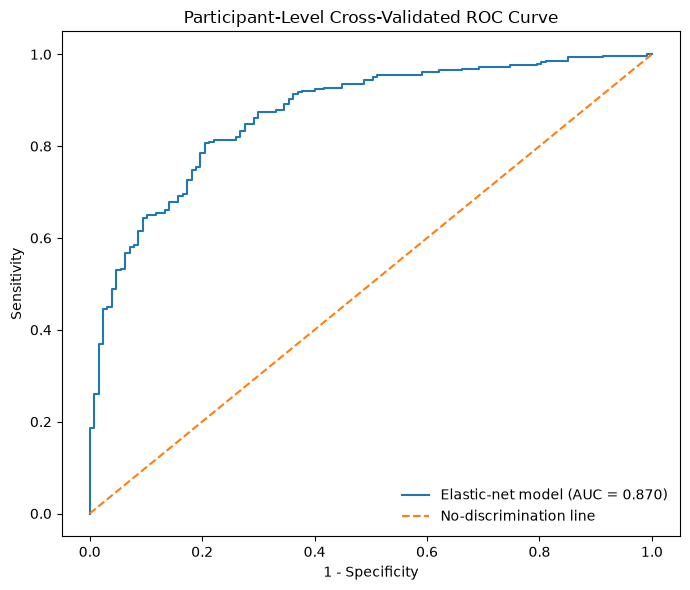

In [23]:
# Use participant-level repeated-CV probabilities.
roc_fpr, roc_tpr, _ = roc_curve(
    calibration_summary["Observed"],
    calibration_summary["Predicted_probability"]
)
roc_auc = roc_auc_score(
    calibration_summary["Observed"],
    calibration_summary["Predicted_probability"]
)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(roc_fpr, roc_tpr, label=f"Elastic-net model (AUC = {roc_auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", label="No-discrimination line")
ax.set_xlabel("1 - Specificity")
ax.set_ylabel("Sensitivity")
ax.set_title("Participant-Level Cross-Validated ROC Curve")
ax.legend(frameon=False)
fig.tight_layout()
print("Saved:", save_figure(fig, "Figure_4_7_ElasticNet_ROC.png"))
plt.show()
plt.close(fig)

# PART D — HYPOTHESIS-SPECIFIC LOGISTIC MODELS

These models are separate from the primary elastic-net prediction model. They are used to estimate the prespecified hypotheses H1–H5 with compact covariate sets.

## D1. Build the hypothesis-analysis design matrix

In [24]:
# ============================================================
# D1. BUILD THE HYPOTHESIS-ANALYSIS DESIGN MATRIX
# ============================================================

# ------------------------------------------------------------
# 1. Helper functions
# ------------------------------------------------------------

def standardise_and_impute(series):
    """
    Convert a variable to numeric, standardise it using the
    sample standard deviation, and mean-impute missing values.

    After standardisation, the mean is zero, so missing values
    are replaced with zero.
    """
    numeric_series = pd.to_numeric(
        series,
        errors="coerce"
    ).astype(float)

    mean_value = numeric_series.mean()
    standard_deviation = numeric_series.std(ddof=1)

    # Protect against a completely missing or constant variable
    if (
        pd.isna(standard_deviation)
        or np.isclose(standard_deviation, 0)
    ):
        return pd.Series(
            np.zeros(len(numeric_series), dtype=float),
            index=numeric_series.index
        )

    standardised = (
        numeric_series - mean_value
    ) / standard_deviation

    return standardised.fillna(0.0)


def binary_indicator(series, positive_value):
    """
    Create a 0/1 indicator safely from a categorical variable.

    Missing values are initially coded as zero, while a separate
    missingness indicator should be created where relevant.
    """
    cleaned_series = (
        series
        .astype("string")
        .str.strip()
    )

    return (
        cleaned_series
        .eq(positive_value)
        .fillna(False)
        .astype(int)
    )


def missing_indicator(series):
    """
    Create a separate indicator for missing categorical values.
    """
    return series.isna().astype(int)


def clean_categorical(series):
    """
    Clean categorical values and assign missing observations
    to an explicit 'Unknown' category.
    """
    return (
        series
        .astype("string")
        .str.strip()
        .fillna("Unknown")
    )


# ------------------------------------------------------------
# 2. Initialise the design matrix
# ------------------------------------------------------------

EXPO = [
    "fac_adh",
    "fac_int",
    "home_adh"
]

D = pd.DataFrame(index=df.index)

# Ensure the early-rehabilitation indicator is a complete integer variable
D["early"] = (
    pd.to_numeric(
        model_df["Early_rehabilitation"],
        errors="coerce"
    )
    .fillna(0)
    .astype(int)
)

# Validate early-rehabilitation coding
unexpected_early_values = set(
    D["early"].dropna().unique()
) - {0, 1}

if unexpected_early_values:
    raise ValueError(
        "Early_rehabilitation must contain only 0 and 1. "
        f"Unexpected values: {unexpected_early_values}"
    )


# ------------------------------------------------------------
# 3. Primary rehabilitation exposure variables
# ------------------------------------------------------------

# Recorded exposure measures are primary.
# Zero intensity was previously converted to missing in
# Facility_intensity_primary.
D["fac_adh"] = standardise_and_impute(
    df["Facility therapy adherence (%)"]
)

D["fac_int"] = standardise_and_impute(
    model_df["Facility_intensity_primary"]
)

D["home_adh"] = standardise_and_impute(
    df["Caregiver adherence to home programme (%)"]
)


# ------------------------------------------------------------
# 4. Home-programme training variables
# ------------------------------------------------------------

home_training = (
    df["Caregiver completed home-program training?"]
    .astype("string")
    .str.strip()
)

# No training: 1 = No, 0 = Yes or missing
D["no_home_training"] = (
    home_training
    .eq("No")
    .fillna(False)
    .astype(int)
)

# Preserve information about missing training status
D["home_training_missing"] = (
    home_training
    .isna()
    .astype(int)
)


# ------------------------------------------------------------
# 5. Caregiver and therapy continuity variables
# ------------------------------------------------------------

D["conf"] = standardise_and_impute(
    df["Caregiver confidence score"]
)

D["missed"] = standardise_and_impute(
    df["Total therapy sessions missed"]
)

D["interrupt"] = standardise_and_impute(
    df["Longest therapy interruption (days)"]
)


# ------------------------------------------------------------
# 6. Baseline clinical variables
# ------------------------------------------------------------

gmfcs_clean = (
    df["GMFCS level at baseline"]
    .astype("string")
    .str.strip()
)

gmfcs_numeric = gmfcs_clean.map(LEVEL)

# Display any GMFCS labels that were not recognised
unmapped_gmfcs = sorted(
    gmfcs_clean[
        gmfcs_clean.notna() &
        gmfcs_numeric.isna()
    ].dropna().unique()
)

if unmapped_gmfcs:
    print(
        "Warning: Unrecognised GMFCS labels:",
        unmapped_gmfcs
    )

D["GMFCS"] = standardise_and_impute(
    gmfcs_numeric
)

D["GMFM_base"] = standardise_and_impute(
    df["GMFM total score at baseline (%)"]
)

D["VABS_base"] = standardise_and_impute(
    df["VABS overall/composite score at baseline"]
)

D["CPQoL_base"] = standardise_and_impute(
    df["CPQoL overall score at baseline"]
)

D["prev_dur"] = standardise_and_impute(
    df["Duration of previous rehabilitation (months)"]
)

D["distance"] = standardise_and_impute(
    df["Distance to primary rehabilitation facility (km)"]
)


# ------------------------------------------------------------
# 7. Binary contextual variables
# ------------------------------------------------------------

D["female"] = binary_indicator(
    df["Child sex"],
    "Female"
)

D["social_support"] = binary_indicator(
    df["Adequate social support reported?"],
    "Yes"
)

D["food_insecure"] = binary_indicator(
    df[
        "Household experienced food insecurity "
        "in past 30 days?"
    ],
    "Yes"
)

D["insured"] = binary_indicator(
    df["Health insurance available?"],
    "Yes"
)


# ------------------------------------------------------------
# 8. Multicategory contextual variables
# ------------------------------------------------------------

categorical_context = pd.DataFrame(
    {
        "site": clean_categorical(
            df["Study site"]
        ),
        "cptype": clean_categorical(
            df["Primary cerebral palsy type"]
        ),
        "region": clean_categorical(
            df["Predominantly affected body region"]
        ),
        "educ": clean_categorical(
            df["Caregiver highest education level"]
        ),
        "income": clean_categorical(
            df["Household income band"]
        )
    },
    index=df.index
)

dummies = pd.get_dummies(
    categorical_context,
    drop_first=True,
    dtype=int
)

# Create clean and consistent dummy-variable names
dummies.columns = [
    column
    .replace(" ", "_")
    .replace("/", "_")
    .replace("-", "_")
    .replace("?", "")
    for column in dummies.columns
]

# Protect against duplicate names after cleaning
if dummies.columns.duplicated().any():
    duplicate_names = (
        dummies.columns[
            dummies.columns.duplicated()
        ]
        .unique()
        .tolist()
    )

    raise ValueError(
        "Duplicate dummy-variable names were created: "
        f"{duplicate_names}"
    )

D = pd.concat(
    [D, dummies],
    axis=1
)


# ------------------------------------------------------------
# 9. Age-stratified exposure variables
# ------------------------------------------------------------

for exposure in EXPO:

    # Effect of exposure among early starters
    D[f"{exposure}_early"] = (
        D["early"] * D[exposure]
    )

    # Effect of exposure among later starters
    D[f"{exposure}_late"] = (
        (1 - D["early"]) * D[exposure]
    )


# ------------------------------------------------------------
# 10. Identify contextual dummy columns
# ------------------------------------------------------------

site_cols = [
    column
    for column in D.columns
    if column.startswith("site_")
]

ctx_dummies = [
    column
    for column in D.columns
    if column.startswith(
        (
            "cptype_",
            "region_",
            "educ_",
            "income_"
        )
    )
]


# ------------------------------------------------------------
# 11. Define model covariate sets
# ------------------------------------------------------------

BASELINE = [
    "GMFCS",
    "GMFM_base",
    "VABS_base",
    "CPQoL_base"
]

CORE_COV = (
    [
        "GMFCS",
        "GMFM_base",
        "prev_dur"
    ]
    + site_cols
)

# H1 and pooled-exposure model
cols_A_core = (
    ["early"]
    + EXPO
    + [
        "no_home_training",
        "home_training_missing",
        "conf"
    ]
    + CORE_COV
)

# Age-stratified exposure model
cols_B_core = (
    ["early"]
    + [
        f"{exposure}_{group}"
        for exposure in EXPO
        for group in ("early", "late")
    ]
    + [
        "no_home_training",
        "home_training_missing",
        "conf"
    ]
    + CORE_COV
)


# ------------------------------------------------------------
# 12. Final validation
# ------------------------------------------------------------

# Convert every design-matrix column to an ordinary numeric type
for column in D.columns:
    D[column] = pd.to_numeric(
        D[column],
        errors="coerce"
    ).astype(float)

# Replace infinite values with missing and then mean-impute
D = D.replace(
    [np.inf, -np.inf],
    np.nan
)

D = D.fillna(
    D.mean(numeric_only=True)
)

# Any all-missing columns cannot be mean-imputed
remaining_missing = D.columns[
    D.isna().any()
].tolist()

if remaining_missing:
    raise ValueError(
        "These design-matrix variables still contain missing "
        f"values: {remaining_missing}"
    )

# Verify that the required model columns exist
required_model_columns = sorted(
    set(cols_A_core + cols_B_core)
)

missing_model_columns = [
    column
    for column in required_model_columns
    if column not in D.columns
]

if missing_model_columns:
    raise KeyError(
        "Required model variables are missing: "
        f"{missing_model_columns}"
    )

# Verify that all model values are finite
if not np.isfinite(
    D[required_model_columns].to_numpy(dtype=float)
).all():
    raise ValueError(
        "The hypothesis design matrix contains non-finite values."
    )


# ------------------------------------------------------------
# 13. Display design-matrix summary
# ------------------------------------------------------------

print("Hypothesis design matrix created successfully.")
print("Participants:", D.shape[0])
print("Total design-matrix variables:", D.shape[1])
print("H1/pooled model variables:", len(cols_A_core))
print(
    "Age-stratified exposure model variables:",
    len(cols_B_core)
)
print(
    "Missing values in required model variables:",
    int(D[required_model_columns].isna().sum().sum())
)

print("\nHome-programme training status:")
display(
    pd.DataFrame({
        "No training": [
            int(D["no_home_training"].sum())
        ],
        "Missing training status": [
            int(D["home_training_missing"].sum())
        ]
    })
)

Hypothesis design matrix created successfully.
Participants: 416
Total design-matrix variables: 46
H1/pooled model variables: 13
Age-stratified exposure model variables: 16
Missing values in required model variables: 0

Home-programme training status:


,No training,Missing training status
0,144,5


## D2. Fit unpenalised logistic models and calculate hypothesis estimates

In [25]:
def fit_logit(Xd, yd):
    Xm = np.column_stack([np.ones(len(Xd)), Xd.values.astype(float)])
    model = LogisticRegression(
        penalty=None,
        solver="lbfgs",
        fit_intercept=False,
        max_iter=10000
    )
    model.fit(Xm, yd)

    beta = model.coef_.ravel()
    p = np.clip(expit(Xm @ beta), 1e-12, 1 - 1e-12)

    W = p * (1 - p)
    covariance = np.linalg.inv(
        Xm.T @ (Xm * W[:, None])
    )

    log_likelihood = np.sum(
        yd * np.log(p) + (1 - yd) * np.log(1 - p)
    )

    return {
        "names": ["const"] + list(Xd.columns),
        "beta": beta,
        "cov": covariance,
        "ll": log_likelihood,
        "k": len(beta)
    }

def contrast(fit, weights):
    w = np.zeros(fit["k"])
    for name, value in weights.items():
        w[fit["names"].index(name)] = value

    estimate = w @ fit["beta"]
    se = np.sqrt(w @ fit["cov"] @ w)

    return {
        "OR": np.exp(estimate),
        "CI_low": np.exp(estimate - 1.96 * se),
        "CI_high": np.exp(estimate + 1.96 * se),
        "p": 2 * (1 - stats.norm.cdf(abs(estimate / se)))
    }

def wald_joint(fit, names):
    idx = [fit["names"].index(n) for n in names]
    b = fit["beta"][idx]
    V = fit["cov"][np.ix_(idx, idx)]
    chi2 = float(b @ np.linalg.solve(V, b))
    df_joint = len(idx)
    p = 1 - stats.chi2.cdf(chi2, df_joint)
    return chi2, df_joint, p

fit_A = fit_logit(D[cols_A_core], y.to_numpy())
fit_B = fit_logit(D[cols_B_core], y.to_numpy())

hypothesis_rows = []

def add_hypothesis(hypothesis, estimate, fit, weights):
    r = contrast(fit, weights)
    hypothesis_rows.append({
        "Hypothesis": hypothesis,
        "Estimate": estimate,
        "OR": r["OR"],
        "95% CI lower": r["CI_low"],
        "95% CI upper": r["CI_high"],
        "p-value": r["p"]
    })

add_hypothesis("H1", "Early (<24 months) vs later start", fit_A, {"early": 1})

for exposure, label in [
    ("fac_adh", "Facility adherence"),
    ("fac_int", "Facility intensity"),
    ("home_adh", "Home adherence")
]:
    add_hypothesis("H2", f"{label} — early starters", fit_B, {f"{exposure}_early": 1})
    add_hypothesis("H3", f"{label} — later starters", fit_B, {f"{exposure}_late": 1})
    add_hypothesis("H4", f"{label} — pooled", fit_A, {exposure: 1})

add_hypothesis(
    "H4",
    "No home-programme training vs training",
    fit_A,
    {"no_home_training": 1}
)

add_hypothesis("H5", "GMFCS per SD", fit_A, {"GMFCS": 1})
add_hypothesis("H5", "Baseline GMFM per SD", fit_A, {"GMFM_base": 1})

hypothesis_table = pd.DataFrame(hypothesis_rows).round(3)
display(hypothesis_table)
save_table(hypothesis_table, "Table_D1_Hypothesis_Estimates.csv")
save_result(hypothesis_table, "Hypothesis_Specific_Logistic_Regression_Results.csv")

,Hypothesis,Estimate,OR,95% CI lower,95% CI upper,p-value
0,H1,Early (<24 months) vs later start,10.296,5.132,20.653,0.000
1,H2,Facility adherence — early starters,1.527,0.726,3.215,0.265
2,H3,Facility adherence — later starters,1.935,1.177,3.179,0.009
3,H4,Facility adherence — pooled,1.855,1.228,2.802,0.003
4,H2,Facility intensity — early starters,1.522,0.856,2.707,0.153
5,H3,Facility intensity — later starters,2.061,1.386,3.064,0.000
6,H4,Facility intensity — pooled,1.917,1.383,2.657,0.000
7,H2,Home adherence — early starters,3.160,1.292,7.725,0.012
8,H3,Home adherence — later starters,1.182,0.769,1.816,0.446
9,H4,Home adherence — pooled,1.407,0.961,2.059,0.079


WindowsPath('C:/Users/hp/Documents/MSc_Thesis_Analysis/05_Results/Hypothesis_Specific_Logistic_Regression_Results.csv')

## D3. Joint tests and age-stratum interaction

In [26]:
# H2 joint test
h2_joint = wald_joint(
    fit_B,
    [f"{v}_early" for v in EXPO]
)

# H3 joint test
h3_joint = wald_joint(
    fit_B,
    [f"{v}_late" for v in EXPO]
)

# Pooled exposure joint test
h4_joint = wald_joint(
    fit_A,
    EXPO
)

# Likelihood-ratio test: pooled exposure model vs age-stratified slopes
lrt = 2 * (fit_B["ll"] - fit_A["ll"])
lrt_df = 3
lrt_p = 1 - stats.chi2.cdf(lrt, lrt_df)

joint_tests = pd.DataFrame({
    "Test": [
        "H2: early-starter exposure slopes",
        "H3: later-starter exposure slopes",
        "H4: pooled exposure effects",
        "Age-stratum interaction: pooled vs age-stratified"
    ],
    "Chi-square": [
        h2_joint[0], h3_joint[0], h4_joint[0], lrt
    ],
    "df": [
        h2_joint[1], h3_joint[1], h4_joint[1], lrt_df
    ],
    "p-value": [
        h2_joint[2], h3_joint[2], h4_joint[2], lrt_p
    ]
}).round(3)

display(joint_tests)
save_table(joint_tests, "Table_D2_Hypothesis_Joint_Tests.csv")
save_result(joint_tests, "Hypothesis_Joint_Test_Results.csv")

,Test,Chi-square,df,p-value
0,H2: early-starter exposure slopes,10.826,3,0.013
1,H3: later-starter exposure slopes,21.491,3,0.000
2,H4: pooled exposure effects,28.500,3,0.000
3,Age-stratum interaction: pooled vs age-stratified,4.855,3,0.183


WindowsPath('C:/Users/hp/Documents/MSc_Thesis_Analysis/05_Results/Hypothesis_Joint_Test_Results.csv')

## D4. Forest plot of hypothesis-specific estimates

Saved: C:\Users\hp\Documents\MSc_Thesis_Analysis\06_Figures\Figure_4_8_Hypothesis_Forest_Plot.png


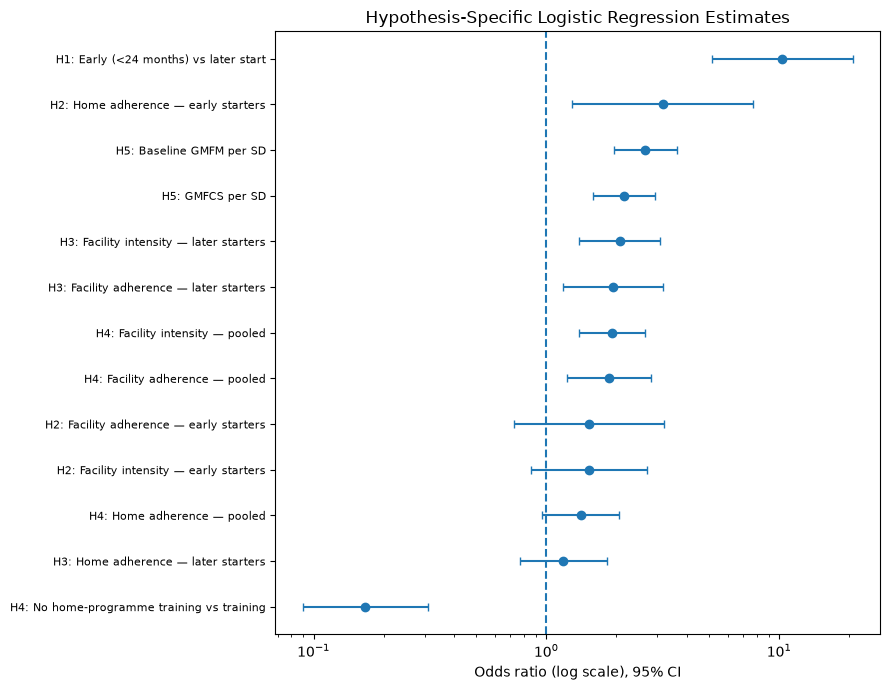

In [27]:
plot_h = hypothesis_table.copy()
plot_h = plot_h.sort_values("OR").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 7))
ypos = np.arange(len(plot_h))
x = plot_h["OR"].to_numpy()
lo = plot_h["95% CI lower"].to_numpy()
hi = plot_h["95% CI upper"].to_numpy()

ax.errorbar(
    x, ypos,
    xerr=[x-lo, hi-x],
    fmt="o",
    capsize=3
)
ax.axvline(1, linestyle="--")
ax.set_xscale("log")
ax.set_yticks(ypos)
ax.set_yticklabels(
    [f"{h}: {e}" for h, e in zip(plot_h["Hypothesis"], plot_h["Estimate"])],
    fontsize=8
)
ax.set_xlabel("Odds ratio (log scale), 95% CI")
ax.set_title("Hypothesis-Specific Logistic Regression Estimates")
fig.tight_layout()
print("Saved:", save_figure(fig, "Figure_4_8_Hypothesis_Forest_Plot.png"))
plt.show()
plt.close(fig)

# PART E — VERIFICATION AND SENSITIVITY CHECKS

These checks are retained from the original notebook but consolidated so that the same calculation is not repeated in multiple sections.

## E1. Independent recomputation of the ONS

In [28]:
H = lambda c: 6 - df[c].map(LEVEL)

dH_mac = pd.Series(
    np.where(
        use_mini,
        H("Mini-MACS level at follow-up") - H("Mini-MACS level at baseline"),
        H("MACS level at follow-up") - H("MACS level at baseline")
    ),
    index=df.index
)

ind = {
    "GMFM": df["GMFM total score at follow-up (%)"] - df["GMFM total score at baseline (%)"],
    "MACS": dH_mac,
    "VABS": df["VABS overall/composite score at follow-up"] - df["VABS overall/composite score at baseline"],
    "CFCS": H("CFCS level at follow-up") - H("CFCS level at baseline"),
    "VABScom": df["VABS communication domain.1"] - df["VABS communication domain"],
    "CPQpart": df["CPQoL participation domain.1"] - df["CPQoL participation domain"],
    "VABSsoc": df["VABS socialization domain.1"] - df["VABS socialization domain"],
    "CPQ": df["CPQoL overall score at follow-up"] - df["CPQoL overall score at baseline"]
}

S = {
    k: (v - v.mean()) / v.std(ddof=1)
    for k, v in ind.items()
}

D_ind = pd.DataFrame({
    "GM": S["GMFM"],
    "MA": S["MACS"],
    "AF": S["VABS"],
    "COM": (S["CFCS"] + S["VABScom"]) / 2,
    "PART": (S["CPQpart"] + S["VABSsoc"]) / 2,
    "HR": S["CPQ"]
})

ONS_independent = D_ind.mean(axis=1)

max_difference = np.abs(ONS_independent - ONS).max()

print(f"Maximum absolute difference between primary and independently recomputed ONS: {max_difference:.12f}")

assert max_difference < 1e-10

Maximum absolute difference between primary and independently recomputed ONS: 0.000000000000


## E2. Baseline severity and classification verification

In [31]:
severity = pd.DataFrame({
    "GMFCS": df["GMFCS level at baseline"].map(LEVEL),
    "MACS": df["MACS level at baseline"].map(LEVEL),
    "Mini-MACS": df["Mini-MACS level at baseline"].map(LEVEL),
    "CFCS": df["CFCS level at baseline"].map(LEVEL),
    "EDACS": df["EDACS level at baseline"].map(LEVEL),
    "GMFM": df["GMFM total score at baseline (%)"],
    "VABS": df["VABS overall/composite score at baseline"],
    "CPQoL": df["CPQoL overall score at baseline"]
})

severity_corr = severity.corr(method="spearman").round(3)
display(severity_corr)
save_table(
    severity_corr.reset_index().rename(columns={"index": "Variable"}),
    "Table_E1_Baseline_Severity_Correlations.csv"
)
save_result(severity_corr, "Baseline_Severity_Correlation_Results.csv")

classification_pairs = {
    "GMFCS": ("GMFCS level at baseline", "GMFCS level at follow-up"),
    "MACS": ("MACS level at baseline", "MACS level at follow-up"),
    "Mini-MACS": ("Mini-MACS level at baseline", "Mini-MACS level at follow-up"),
    "CFCS": ("CFCS level at baseline", "CFCS level at follow-up"),
    "EDACS": ("EDACS level at baseline", "EDACS level at follow-up")
}

stability = []
for name, (b, f) in classification_pairs.items():
    rho = stats.spearmanr(
        df[b].map(LEVEL),
        df[f].map(LEVEL)
    ).statistic
    stability.append({"Classification": name, "Baseline-follow-up Spearman rho": rho})

stability_table = pd.DataFrame(stability).round(3)
display(stability_table)
save_table(stability_table, "Table_E2_Classification_Stability.csv")
save_result(stability_table, "ONS_Classification_Stability_Results.csv")

,GMFCS,MACS,Mini-MACS,CFCS,EDACS,GMFM,VABS,CPQoL
GMFCS,1.000,0.897,0.810,0.851,0.874,-0.007,-0.003,-0.005
MACS,0.897,1.000,0.914,0.750,0.748,-0.022,-0.034,-0.013
Mini-MACS,0.810,0.914,1.000,0.691,0.673,-0.029,-0.042,-0.035
CFCS,0.851,0.750,0.691,1.000,0.764,0.010,0.024,0.012
EDACS,0.874,0.748,0.673,0.764,1.000,-0.002,0.004,-0.014
GMFM,-0.007,-0.022,-0.029,0.010,-0.002,1.000,0.852,0.650
VABS,-0.003,-0.034,-0.042,0.024,0.004,0.852,1.000,0.609
CPQoL,-0.005,-0.013,-0.035,0.012,-0.014,0.650,0.609,1.000


,Classification,Baseline-follow-up Spearman rho
0,GMFCS,0.048
1,MACS,0.041
2,Mini-MACS,0.333
3,CFCS,0.042
4,EDACS,-0.043


WindowsPath('C:/Users/hp/Documents/MSc_Thesis_Analysis/05_Results/ONS_Classification_Stability_Results.csv')

## E3. Recorded versus reconstructed rehabilitation exposure checks

In [32]:
therapy_types = ["PT", "OT", "Speech", "Feeding"]

attended = df[[f"{t}_attended" for t in therapy_types]].sum(axis=1)
prescribed = df[[f"{t}_prescribed" for t in therapy_types]].sum(axis=1)

home_completed = df[[f"{t}_home_completed" for t in therapy_types]].sum(axis=1)
home_prescribed = df[[f"{t}_home_prescribed" for t in therapy_types]].sum(axis=1)

recorded_facility_adherence = df["Facility therapy adherence (%)"]

raw_exposure_check = pd.DataFrame({
    "Check": [
        "Attended > prescribed",
        "Home completed > home prescribed",
        "Recorded missed sessions = prescribed - attended"
    ],
    "Count": [
        int((attended > prescribed).sum()),
        int((home_completed > home_prescribed).sum()),
        int(
            (
                df["Total therapy sessions missed"]
                == prescribed - attended
            ).sum()
        )
    ]
})

display(raw_exposure_check)
save_table(raw_exposure_check, "Table_E3_Exposure_Field_Consistency.csv")
save_result(raw_exposure_check, "Therapy_Exposure_Consistency_Results.csv")

# Diagnostic correlations, without replacing recorded primary variables.
diag = []

mask = df["Caregiver adherence to home programme (%)"].notna() & (home_prescribed > 0)
if mask.sum() > 1:
    diag.append({
        "Recorded measure": "Home adherence",
        "Reconstructed measure": "Home completed / home prescribed",
        "Pearson r": df.loc[mask, "Caregiver adherence to home programme (%)"].corr(
            100 * home_completed[mask] / home_prescribed[mask]
        )
    })

mask = df["Facility therapy adherence (%)"].notna() & (prescribed > 0)
if mask.sum() > 1:
    diag.append({
        "Recorded measure": "Facility adherence",
        "Reconstructed measure": "Attended / prescribed",
        "Pearson r": recorded_facility_adherence[mask].corr(
            100 * attended[mask] / prescribed[mask]
        )
    })

exposure_diagnostics = pd.DataFrame(diag).round(3)
display(exposure_diagnostics)
save_table(exposure_diagnostics, "Table_E4_Recorded_vs_Reconstructed_Exposure.csv")
save_result(exposure_diagnostics, "Recorded_vs_Reconstructed_Exposure_Results.csv")

,Check,Count
0,Attended > prescribed,0
1,Home completed > home prescribed,0
2,Recorded missed sessions = prescribed - attended,8


,Recorded measure,Reconstructed measure,Pearson r
0,Home adherence,Home completed / home prescribed,-0.044
1,Facility adherence,Attended / prescribed,-0.043


WindowsPath('C:/Users/hp/Documents/MSc_Thesis_Analysis/05_Results/Recorded_vs_Reconstructed_Exposure_Results.csv')

# PART F — FINAL ANALYSIS DATASET AND OUTPUT INVENTORY

The final export contains the participant ID, ONS components, continuous ONS, primary binary ONS, sensitivity outcomes and extreme-change flag. Predictor modelling variables remain defined separately to avoid accidental leakage.

In [35]:
# ============================================================
# FINAL OUTPUT INVENTORY
# ============================================================

# Identify all generated output files
result_files = sorted(
    RESULTS_DIR.glob("*")
)

figure_files = sorted(
    FIGURE_DIR.glob("Figure_*.png")
)

table_files = sorted(
    TABLE_DIR.glob("Table_*.csv")
)


# ------------------------------------------------------------
# Display results inventory
# ------------------------------------------------------------

print(
    "\nResults generated:",
    len(result_files)
)

for path in result_files:
    print(" -", path.name)


# ------------------------------------------------------------
# Display figure inventory
# ------------------------------------------------------------

print(
    "\nFigures generated:",
    len(figure_files)
)

for path in figure_files:
    print(" -", path.name)


# ------------------------------------------------------------
# Display table inventory
# ------------------------------------------------------------

print(
    "\nTables generated:",
    len(table_files)
)

for path in table_files:
    print(" -", path.name)


# ------------------------------------------------------------
# Record completion in the analysis log
# ------------------------------------------------------------

logger.info(
    "Analysis completed successfully | "
    "results=%s | figures=%s | tables=%s",
    len(result_files),
    len(figure_files),
    len(table_files)
)

# Flush the log so all entries are written immediately
for handler in logger.handlers:
    handler.flush()


# ------------------------------------------------------------
# Display final folder locations
# ------------------------------------------------------------

print("\nAnalysis completed successfully.")

print(
    "Analysis dataset:",
    OUT_PATH
)

print(
    "Results folder:",
    RESULTS_DIR
)

print(
    "Figures folder:",
    FIGURE_DIR
)

print(
    "Tables folder:",
    TABLE_DIR
)

print(
    "Analysis log:",
    LOG_PATH
)


Results generated: 20
 - .ipynb_checkpoints
 - Baseline_Severity_Correlation_Results.csv
 - ElasticNet_Bootstrap_Run_Summary.csv
 - ElasticNet_Bootstrap_Stability_Results.csv
 - ElasticNet_Calibration_Predictions.csv
 - ElasticNet_Calibration_Results.csv
 - ElasticNet_Out_of_Fold_Predictions.csv
 - ElasticNet_Outer_Fold_Results.csv
 - ElasticNet_Performance_Summary.csv
 - Final_ElasticNet_Coefficients.csv
 - Final_ElasticNet_Model_Summary.csv
 - Hypothesis_Joint_Test_Results.csv
 - Hypothesis_Specific_Logistic_Regression_Results.csv
 - ONS_Anchor_Confusion_Matrix.csv
 - ONS_Anchor_ROC_Results.csv
 - ONS_Candidate_Threshold_Results.csv
 - ONS_Classification_Stability_Results.csv
 - ONS_Threshold_Bootstrap_Results.csv
 - Recorded_vs_Reconstructed_Exposure_Results.csv
 - Therapy_Exposure_Consistency_Results.csv

Figures generated: 8
 - Figure_4_1_Primary_Binary_ONS_Distribution.png
 - Figure_4_2_Continuous_ONS_Thresholds.png
 - Figure_4_3_ONS_Anchor_ROC.png
 - Figure_4_4_Numerical_Predic